In [1]:
from EnergyDataLoader.energydataloader import EnergyDataLoader
import plotly.express as px
import pandas as pd
from datetime import datetime, timedelta, date, time
ed = EnergyDataLoader('gansu')
import numpy as np
import chinese_calendar as calendar
import os
import matplotlib.pyplot as plt


In [4]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import os

def find_optimal_dbscan_params(data_scaled, k=4, eps_range=None, min_samples_range=None):
    """
    Find optimal DBSCAN parameters using k-distance graph and grid search
    
    Parameters:
    -----------
    data_scaled : array-like
        Standardized input data
    k : int
        Number of nearest neighbors for k-distance graph (default: 4)
    eps_range : list
        Range of eps values to test (if None, auto-generated)
    min_samples_range : list
        Range of min_samples values to test (if None, auto-generated)
    """
    print("Finding optimal DBSCAN parameters...")
    
    # Method 1: k-distance graph to estimate eps
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data_scaled)
    distances, indices = neighbors_fit.kneighbors(data_scaled)
    
    # Sort distances to k-th nearest neighbor
    k_distances = np.sort(distances[:, k-1], axis=0)
    
    # Plot k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(k_distances)), k_distances)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-NN Distance')
    plt.title(f'{k}-Distance Graph for DBSCAN eps Selection')
    plt.grid(True, alpha=0.3)
    
    # Find elbow point (knee) in k-distance graph
    # Simple method: find point with maximum second derivative
    if len(k_distances) > 10:
        # Calculate second derivative
        second_deriv = np.diff(k_distances, 2)
        knee_point = np.argmax(second_deriv) + 2
        suggested_eps = k_distances[knee_point]
    else:
        suggested_eps = np.percentile(k_distances, 85)  # 85th percentile as fallback
    
    plt.axhline(y=suggested_eps, color='r', linestyle='--', 
                label=f'Suggested eps = {suggested_eps:.3f}')
    plt.legend()
    
    return suggested_eps, k_distances

def evaluate_dbscan_clustering(data_scaled, eps, min_samples):
    """
    Evaluate DBSCAN clustering quality using silhouette score and other metrics
    """
    try:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(data_scaled)
        
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        if n_clusters < 2:  # Need at least 2 clusters for silhouette score
            return {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_ratio': n_noise / len(cluster_labels),
                'silhouette_score': -1,  # Invalid
                'labels': cluster_labels
            }
        
        # Calculate silhouette score (only for non-noise points)
        from sklearn.metrics import silhouette_score
        non_noise_mask = cluster_labels != -1
        if np.sum(non_noise_mask) > 1:
            sil_score = silhouette_score(data_scaled[non_noise_mask], 
                                       cluster_labels[non_noise_mask])
        else:
            sil_score = -1
        
        return {
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise / len(cluster_labels),
            'silhouette_score': sil_score,
            'labels': cluster_labels
        }
    
    except Exception as e:
        print(f"Error evaluating eps={eps}, min_samples={min_samples}: {e}")
        return None

def find_optimal_clusters_dbscan(df, selected_features=None, save_plots=True, save_dir=None):
    """
    DBSCAN-based clustering with automatic parameter optimization
    """
    # Set matplotlib backend for consistent plotting
    if save_plots:
        matplotlib.use('Agg')
    
    # Create save directory
    if save_dir is None:
        save_dir = './dbscan_clustering_results'
    os.makedirs(save_dir, exist_ok=True)
    
    print("Starting DBSCAN clustering analysis...")
    
    # Data preprocessing (same as before)
    df = df.drop(columns=['latitude', 'longitude','location_name','p10fg6'], errors='ignore')

    prefixes = [
       'd2m', 'skt', 'wbt', 'ws10m', 'ws100m', 'fg10', 'tcc', 'hcc', 
       'ssr', 'tp', 'rh', 'vpd'
    ]

    weather_features = [col for col in df.columns if any(col.startswith(prefix) for prefix in prefixes)]
    print(f"Found weather features: {weather_features}")
    
    df = df.dropna(subset=weather_features)
    print(f"Data shape after dropping NaN: {df.shape}")
    
    # Get weather features averages across locations
    df_means = df[weather_features].groupby(df.index).mean()
    df_resampled = df_means.resample('30T').interpolate(method='linear')

    # Ensure the index goes up to 23:30
    last_date = df_resampled.index[-1].date()
    expected_end = pd.Timestamp(f"{last_date} 23:30:00")

    if df_resampled.index[-1] != expected_end:
        new_index = pd.date_range(
            start=df_resampled.index[0],
            end=expected_end,
            freq='30T'
        )
        df_resampled = df_resampled.reindex(new_index)
        df_resampled = df_resampled.fillna(method='ffill')

    # Add time features
    df_resampled['hour'] = df_resampled.index.hour
    df_resampled['is_weekend'] = (df_resampled.index.weekday >= 5).astype(int)
    df_resampled['time_of_day'] = df_resampled['hour'].apply(lambda x: 
        'night' if x < 6 or x >= 22 else
        'morning' if x < 12 else
        'afternoon' if x < 18 else
        'evening'
    )
    
    time_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}
    df_resampled['time_of_day'] = df_resampled['time_of_day'].map(time_map)
    
    # Handle holiday calculation
    try:
        import calendar
        df_resampled['is_holiday'] = pd.Series(df_resampled.index.date).map(
            lambda d: int(calendar.is_holiday(d)) if hasattr(calendar, 'is_holiday') else 0
        ).values
    except:
        df_resampled['is_holiday'] = 0
        print("Warning: Holiday detection failed, using 0 for all dates")
    
    # Default features if none provided
    if selected_features is None:
        available_features = [
            'ws100m', 'fg10', 'rh', 'tcc', 'tp', 'vpd',
            'is_weekend', 'is_holiday', 'time_of_day', 'd2m', 'skt', 'wbt'
        ]
        selected_features = [f for f in available_features if f in df_resampled.columns]
    
    print(f"Selected features: {selected_features}")
    
    # Prepare data
    data = df_resampled[selected_features].copy()
    data = data.fillna(method='ffill').fillna(method='bfill')
    
    # Standardize features
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    print(f"Scaled data shape: {data_scaled.shape}")
    
    # Step 1: Find optimal eps using k-distance graph
    suggested_eps, k_distances = find_optimal_dbscan_params(data_scaled)
    
    if save_plots:
        kdist_path = os.path.join(save_dir, 'k_distance_graph.png')
        plt.savefig(kdist_path, dpi=150, bbox_inches='tight')
        print(f"k-distance graph saved to: {kdist_path}")
        plt.close()
    else:
        plt.show()
    
    # Step 2: Grid search for optimal parameters
    print("Performing parameter grid search...")
    
    # Define search ranges
    
    eps_range = np.linspace(suggested_eps * 0.5, suggested_eps * 2.0, 15)
    min_samples_range = range(3, min(20, max(5, data_scaled.shape[0] // 50)))
    
    # Evaluate different parameter combinations
    results = []
    for eps in eps_range:
        for min_samples in min_samples_range:
            result = evaluate_dbscan_clustering(data_scaled, eps, min_samples)
            if result:
                results.append(result)
    
    if not results:
        print("No valid clustering results found!")
        return None
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)
    
    # Filter out results with too much noise or too few clusters
    valid_results = results_df[
        (results_df['noise_ratio'] < 0.5) & 
        (results_df['n_clusters'] >= 2) & 
        (results_df['n_clusters'] <= 10) &
        (results_df['silhouette_score'] > 0)
    ]
    
    if valid_results.empty:
        print("No valid results found, using best available...")
        valid_results = results_df[results_df['silhouette_score'] > -1]
    
    # Select best parameters based on silhouette score
    best_result = valid_results.loc[valid_results['silhouette_score'].idxmax()]
    optimal_eps = best_result['eps']
    optimal_min_samples = best_result['min_samples']
    
    print(f"Optimal parameters: eps={optimal_eps:.4f}, min_samples={optimal_min_samples}")
    print(f"Best silhouette score: {best_result['silhouette_score']:.4f}")
    print(f"Number of clusters: {best_result['n_clusters']}")
    print(f"Noise ratio: {best_result['noise_ratio']:.2%}")
    
    # Step 3: Final clustering with optimal parameters
    dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
    cluster_labels = dbscan.fit_predict(data_scaled)
    
    clusters = pd.Series(cluster_labels, index=data.index, name='cluster')
    
    # Calculate cluster profiles (excluding noise points)
    non_noise_data = data[cluster_labels != -1]
    non_noise_labels = cluster_labels[cluster_labels != -1]
    
    if len(non_noise_data) > 0:
        cluster_profiles = non_noise_data.groupby(non_noise_labels).mean()
    else:
        cluster_profiles = pd.DataFrame()
    
    # Step 4: Visualize results
    # Plot parameter search results
    plt.figure(figsize=(15, 5))
    
    # Heatmap of silhouette scores
    plt.subplot(1, 3, 1)
    pivot_sil = results_df.pivot(index='min_samples', columns='eps', values='silhouette_score')
    im1 = plt.imshow(pivot_sil.values, aspect='auto', cmap='viridis')
    plt.colorbar(im1, label='Silhouette Score')
    plt.title('Silhouette Score Heatmap')
    plt.xlabel('eps (index)')
    plt.ylabel('min_samples')
    
    # Heatmap of number of clusters
    plt.subplot(1, 3, 2)
    pivot_clusters = results_df.pivot(index='min_samples', columns='eps', values='n_clusters')
    im2 = plt.imshow(pivot_clusters.values, aspect='auto', cmap='plasma')
    plt.colorbar(im2, label='Number of Clusters')
    plt.title('Number of Clusters Heatmap')
    plt.xlabel('eps (index)')
    plt.ylabel('min_samples')
    
    # Noise ratio heatmap
    plt.subplot(1, 3, 3)
    pivot_noise = results_df.pivot(index='min_samples', columns='eps', values='noise_ratio')
    im3 = plt.imshow(pivot_noise.values, aspect='auto', cmap='Reds')
    plt.colorbar(im3, label='Noise Ratio')
    plt.title('Noise Ratio Heatmap')
    plt.xlabel('eps (index)')
    plt.ylabel('min_samples')
    
    plt.tight_layout()
    
    if save_plots:
        param_path = os.path.join(save_dir, 'parameter_search_heatmaps.png')
        plt.savefig(param_path, dpi=150, bbox_inches='tight')
        print(f"Parameter search heatmaps saved to: {param_path}")
        plt.close()
    else:
        plt.show()
    
    # Step 5: t-SNE visualization
    print("Performing t-SNE visualization...")
    n_samples = data_scaled.shape[0]
    perplexity = min(30, max(5, n_samples // 4))
    
    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
        data_tsne = tsne.fit_transform(data_scaled)
        
        # Create t-SNE plot
        plt.figure(figsize=(12, 8))
        
        unique_clusters = sorted(set(cluster_labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
        
        for i, cluster in enumerate(unique_clusters):
            mask = cluster_labels == cluster
            if cluster == -1:  # Noise points
                plt.scatter(data_tsne[mask, 0], data_tsne[mask, 1], 
                          c='gray', alpha=0.6, s=20, marker='x', label='Noise')
            else:
                plt.scatter(data_tsne[mask, 0], data_tsne[mask, 1], 
                          c=[colors[i]], alpha=0.7, s=50, label=f'Cluster {cluster}')
        
        plt.title(f't-SNE Visualization of DBSCAN Clusters\n'
                 f'eps={optimal_eps:.3f}, min_samples={optimal_min_samples}, '
                 f'clusters={best_result["n_clusters"]}, noise={best_result["noise_ratio"]:.1%}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        if save_plots:
            tsne_path = os.path.join(save_dir, 'dbscan_tsne_visualization.png')
            plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
            print(f"t-SNE visualization saved to: {tsne_path}")
            plt.close()
        else:
            plt.show()
            
        tsne_df = pd.DataFrame(data_tsne, columns=['TSNE1', 'TSNE2'])
        tsne_df['Cluster'] = cluster_labels
        tsne_df.index = data.index
        
    except Exception as e:
        print(f"Error during t-SNE: {e}")
        tsne_df = None
    
    # Step 6: Cluster profiles visualization
    if not cluster_profiles.empty:
        plt.figure(figsize=(12, 8))
        import seaborn as sns
        sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('DBSCAN Cluster Profiles Heatmap')
        plt.xlabel('Cluster')
        plt.ylabel('Features')
        
        if save_plots:
            profiles_path = os.path.join(save_dir, 'dbscan_cluster_profiles.png')
            plt.savefig(profiles_path, dpi=150, bbox_inches='tight')
            print(f"Cluster profiles saved to: {profiles_path}")
            plt.close()
        else:
            plt.show()
    
    print("DBSCAN clustering analysis completed!")
    
    return {
        'optimal_eps': optimal_eps,
        'optimal_min_samples': optimal_min_samples,
        'n_clusters': best_result['n_clusters'],
        'noise_ratio': best_result['noise_ratio'],
        'silhouette_score': best_result['silhouette_score'],
        'clusters': clusters,
        'cluster_profiles': cluster_profiles,
        'tsne_data': tsne_df,
        'parameter_search_results': results_df,
        'scaled_data': data_scaled,
        'feature_names': selected_features,
        'scaler': scaler
    }



In [6]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import os
from scipy import stats
from sklearn.metrics import silhouette_score

def find_optimal_dbscan_params_improved(data_scaled, k_range=[3, 4, 5], eps_method='conservative'):
    """
    Improved method to find optimal DBSCAN parameters
    
    Parameters:
    -----------
    data_scaled : array-like
        Standardized input data
    k_range : list
        Range of k values to test for k-distance (default: [3, 4, 5])
    eps_method : str
        Method for eps estimation: 'conservative', 'knee', 'percentile'
    """
    print("Finding optimal DBSCAN parameters with improved method...")
    
    suggested_eps_values = []
    
    # Test different k values and find multiple eps candidates
    plt.figure(figsize=(15, 5))
    
    for i, k in enumerate(k_range):
        plt.subplot(1, len(k_range), i+1)
        
        neighbors = NearestNeighbors(n_neighbors=k+1)  # +1 because first neighbor is the point itself
        neighbors_fit = neighbors.fit(data_scaled)
        distances, indices = neighbors_fit.kneighbors(data_scaled)
        
        # Sort distances to k-th nearest neighbor (skip first column which is distance to self)
        k_distances = np.sort(distances[:, k], axis=0)
        
        plt.plot(range(len(k_distances)), k_distances, 'b-', alpha=0.7)
        plt.xlabel('Points sorted by distance')
        plt.ylabel(f'{k}-NN Distance')
        plt.title(f'{k}-Distance Graph')
        plt.grid(True, alpha=0.3)
        
        # Multiple methods to find eps
        if eps_method == 'conservative':
            # Use lower percentiles for more clusters
            suggested_eps = np.percentile(k_distances, 70)  # More conservative than 85%
        elif eps_method == 'knee':
            # Improved knee detection using derivative and curvature
            if len(k_distances) > 20:
                # Calculate first and second derivatives
                first_deriv = np.diff(k_distances)
                second_deriv = np.diff(first_deriv)
                
                # Find point with maximum curvature (second derivative)
                if len(second_deriv) > 0:
                    knee_idx = np.argmax(second_deriv) + 2
                    suggested_eps = k_distances[min(knee_idx, len(k_distances)-1)]
                else:
                    suggested_eps = np.percentile(k_distances, 70)
            else:
                suggested_eps = np.percentile(k_distances, 70)
        else:  # percentile method
            suggested_eps = np.percentile(k_distances, 65)  # Even more conservative
        
        suggested_eps_values.append(suggested_eps)
        
        plt.axhline(y=suggested_eps, color='r', linestyle='--', 
                   label=f'Suggested eps = {suggested_eps:.3f}')
        plt.legend()
    
    plt.tight_layout()
    
    # Use the most conservative (smallest) eps suggestion
    final_eps = min(suggested_eps_values)
    print(f"Suggested eps values: {suggested_eps_values}")
    print(f"Using conservative eps: {final_eps:.4f}")
    
    return final_eps, k_distances

def evaluate_dbscan_clustering_improved(data_scaled, eps, min_samples):
    """
    Enhanced DBSCAN evaluation with more metrics
    """
    try:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(data_scaled)
        
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        # Calculate additional metrics
        total_points = len(cluster_labels)
        noise_ratio = n_noise / total_points
        
        # Calculate silhouette score (only for non-noise points)
        sil_score = -1
        if n_clusters >= 2:
            non_noise_mask = cluster_labels != -1
            if np.sum(non_noise_mask) > 1:
                non_noise_data = data_scaled[non_noise_mask]
                non_noise_labels = cluster_labels[non_noise_mask]
                if len(set(non_noise_labels)) >= 2:
                    sil_score = silhouette_score(non_noise_data, non_noise_labels)
        
        # Calculate cluster size statistics
        cluster_sizes = []
        for cluster_id in set(cluster_labels):
            if cluster_id != -1:  # Exclude noise
                cluster_sizes.append(np.sum(cluster_labels == cluster_id))
        
        # Calculate balance score (prefer more balanced clusters)
        if cluster_sizes:
            cluster_sizes = np.array(cluster_sizes)
            balance_score = 1 - (np.std(cluster_sizes) / (np.mean(cluster_sizes) + 1e-8))
        else:
            balance_score = 0
        
        # Composite score combining multiple factors - favor more clusters
        if n_clusters >= 2 and sil_score > -1:
            # Prefer solutions with:
            # - Higher silhouette score
            # - More clusters (bonus for 4-8 clusters, penalty for too few)
            # - Lower noise ratio
            # - Better cluster balance
            
            # Cluster count bonus - reward more clusters up to a point
            if n_clusters >= 6:
                cluster_bonus = 0.3  # Strong bonus for 6+ clusters
            elif n_clusters >= 4:
                cluster_bonus = 0.2  # Good bonus for 4-5 clusters
            elif n_clusters >= 3:
                cluster_bonus = 0.1  # Small bonus for 3 clusters
            else:
                cluster_bonus = -0.2  # Penalty for too few clusters
            
            noise_penalty = min(noise_ratio * 0.4, 0.3)  # Cap noise penalty
            
            composite_score = (sil_score * 0.5 +           # Silhouette quality
                             balance_score * 0.2 +         # Cluster balance
                             cluster_bonus +                # More clusters bonus
                             (1 - noise_penalty) * 0.3)    # Low noise bonus
        else:
            composite_score = -1
        
        return {
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette_score': sil_score,
            'balance_score': balance_score,
            'composite_score': composite_score,
            'labels': cluster_labels,
            'cluster_sizes': cluster_sizes
        }
    
    except Exception as e:
        print(f"Error evaluating eps={eps}, min_samples={min_samples}: {e}")
        return None

def find_optimal_clusters_dbscan_improved(df, selected_features=None, save_plots=True, save_dir=None):
    """
    Improved DBSCAN clustering with better parameter optimization
    """
    # Set matplotlib backend for consistent plotting
    # if save_plots:
    #     matplotlib.use('Agg')
    
    # Create save directory
    if save_dir is None:
        save_dir = './dbscan_clustering_results_improved'
    os.makedirs(save_dir, exist_ok=True)
    
    print("Starting improved DBSCAN clustering analysis...")
    
    # Data preprocessing (same as before)
    df = df.drop(columns=['latitude', 'longitude','location_name','p10fg6'], errors='ignore')

    prefixes = [
       'd2m', 'skt', 'wbt', 'ws10m', 'ws100m','ws200m','fg10', 'tcc', 'hcc', 
     'tp', 'rh', 'vpd','fdir','ssr','sp'
    ]

    weather_features = [col for col in df.columns if any(col.startswith(prefix) for prefix in prefixes)]
    print(f"Found weather features: {weather_features}")
    
    df = df.dropna(subset=weather_features)
    print(f"Data shape after dropping NaN: {df.shape}")
    
    # Get weather features averages across locations
    df_means = df[weather_features].groupby(df.index).mean()
    df_resampled = df_means.resample('30T').interpolate(method='linear')

    # Ensure the index goes up to 23:30
    last_date = df_resampled.index[-1].date()
    expected_end = pd.Timestamp(f"{last_date} 23:30:00")

    if df_resampled.index[-1] != expected_end:
        new_index = pd.date_range(
            start=df_resampled.index[0],
            end=expected_end,
            freq='30T'
        )
        df_resampled = df_resampled.reindex(new_index)
        df_resampled = df_resampled.fillna(method='ffill')
    
    for feature in weather_features:
        if feature in df_resampled.columns:
            # Create 5 quantile bins for each weather feature
            df_resampled[feature] = pd.qcut(df_resampled[feature],5, labels=False, duplicates='drop')
            
    # Add time features
    df_resampled['hour'] = df_resampled.index.hour
    df_resampled['is_weekend'] = (df_resampled.index.weekday >= 5).astype(int)
    df_resampled['time_of_day'] = df_resampled['hour'].apply(lambda x: 
        'night' if x < 6 or x >= 22 else
        'morning' if x < 12 else
        'afternoon' if x < 18 else
        'evening'
    )
    
    time_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}
    df_resampled['time_of_day'] = df_resampled['time_of_day'].map(time_map)
    
    # Handle holiday calculation
    try:
        import calendar
        df_resampled['is_holiday'] = pd.Series(df_resampled.index.date).map(
            lambda d: int(calendar.is_holiday(d)) if hasattr(calendar, 'is_holiday') else 0
        ).values
    except:
        df_resampled['is_holiday'] = 0
        print("Warning: Holiday detection failed, using 0 for all dates")
    
    # Default features if none provided
    if selected_features is None:
        available_features = [
                 'd2m', 
                 'skt', 'wbt', 
                #  'ws10m', 'ws200m',
                 'ws100m',
                 'fg10', 'tcc', 
                #  'hcc', 
     'tp', 'rh', 'vpd','fdir','ssr',
    #  'sp'
            # 'is_weekend', 'is_holiday', 'time_of_day', 
        ]

        selected_features = [f for f in available_features if f in df_resampled.columns]
    
    print(f"Selected features: {selected_features}")
    
    # Prepare data
    data = df_resampled[selected_features].copy()
    data = data.fillna(method='ffill').fillna(method='bfill')
    
    # Standardize features
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    print(f"Scaled data shape: {data_scaled.shape}")
    
    # Step 1: Find optimal eps using improved k-distance analysis
    suggested_eps, k_distances = find_optimal_dbscan_params_improved(
        data_scaled, k_range=[3,4,5], eps_method='conservative'
    )
    # TUNE HERE
    
    if save_plots:
        kdist_path = os.path.join(save_dir, 'improved_k_distance_graphs.png')
        plt.savefig(kdist_path, dpi=150, bbox_inches='tight')
        print(f"k-distance graphs saved to: {kdist_path}")
        plt.close()
    else:
        plt.show()
    
    # Step 2: Improved grid search with finer granularity around suggested eps
    print("Performing improved parameter grid search...")
  







# ============================================================TUNE THIS===============================================================:  
    # More focused search around the suggested eps
    eps_min = suggested_eps * 0.76 # Start from much lower eps
    eps_max = suggested_eps * 0.88# Don't go too high
    eps_range = np.linspace(eps_min, eps_max, 30)  # More granular search
    


    
    # Adaptive min_samples range based on data size
    data_size = data_scaled.shape[0]
    min_samples_max = min(15, max(8, data_size // 30))  # More reasonable upper limit
    min_samples_range = range(2, min_samples_max + 1)  # Start from 2
    
    print(f"Searching eps range: [{eps_min:.4f}, {eps_max:.4f}]")
    print(f"Searching min_samples range: {list(min_samples_range)}")
    
    # Evaluate different parameter combinations
    results = []
    for eps in eps_range:
        for min_samples in min_samples_range:
            result = evaluate_dbscan_clustering_improved(data_scaled, eps, min_samples)
            if result:
                results.append(result)
    
    if not results:
        print("No valid clustering results found!")
        return None
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)
    
    # Enhanced filtering criteria
    valid_results = results_df[
        (results_df['noise_ratio'] < 0.4) &  # Allow slightly more noise
        (results_df['n_clusters'] >= 2) & 
        (results_df['n_clusters'] <= 12) &  # Allow more clusters
        (results_df['composite_score'] > 0)  # Use composite score
    ]
    
    if valid_results.empty:
        print("No valid results with strict criteria, relaxing constraints...")
        valid_results = results_df[
            (results_df['noise_ratio'] < 0.6) & 
            (results_df['n_clusters'] >= 2) &
            (results_df['silhouette_score'] > -0.5)
        ]
    
    if valid_results.empty:
        print("Still no valid results, using best available...")
        valid_results = results_df[results_df['silhouette_score'] > -1]
        if valid_results.empty:
            valid_results = results_df.head(10)  # Take first 10 results
    
    # Select best parameters based on composite score, fallback to silhouette
    if 'composite_score' in valid_results.columns and valid_results['composite_score'].max() > 0:
        best_result = valid_results.loc[valid_results['composite_score'].idxmax()]
        print("Selected based on composite score")
    else:
        best_result = valid_results.loc[valid_results['silhouette_score'].idxmax()]
        print("Selected based on silhouette score")
    
    optimal_eps = best_result['eps']
    optimal_min_samples = best_result['min_samples']
    
    print(f"\nOptimal parameters:")
    print(f"  eps = {optimal_eps:.4f}")
    print(f"  min_samples = {optimal_min_samples}")
    print(f"  Number of clusters = {best_result['n_clusters']}")
    print(f"  Noise ratio = {best_result['noise_ratio']:.2%}")
    print(f"  Silhouette score = {best_result['silhouette_score']:.4f}")
    if 'composite_score' in best_result:
        print(f"  Composite score = {best_result['composite_score']:.4f}")
    
    # Step 3: Final clustering with optimal parameters
    dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
    cluster_labels = dbscan.fit_predict(data_scaled)
    
    clusters = pd.Series(cluster_labels, index=data.index, name='cluster')
    
    # Calculate cluster profiles (excluding noise points)
    non_noise_data = data[cluster_labels != -1]
    non_noise_labels = cluster_labels[cluster_labels != -1]
    
    if len(non_noise_data) > 0:
        cluster_profiles = non_noise_data.groupby(non_noise_labels).mean()
    else:
        cluster_profiles = pd.DataFrame()
    
    # Step 4: Enhanced visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Composite score heatmap
    if len(results_df) > 0 and 'composite_score' in results_df.columns:
        pivot_composite = results_df.pivot(index='min_samples', columns='eps', values='composite_score')
        im1 = axes[0, 0].imshow(pivot_composite.values, aspect='auto', cmap='viridis')
        plt.colorbar(im1, ax=axes[0, 0], label='Composite Score')
        axes[0, 0].set_title('Composite Score Heatmap')
        axes[0, 0].set_xlabel('eps (index)')
        axes[0, 0].set_ylabel('min_samples')
    
    # Plot 2: Number of clusters
    pivot_clusters = results_df.pivot(index='min_samples', columns='eps', values='n_clusters')
    im2 = axes[0, 1].imshow(pivot_clusters.values, aspect='auto', cmap='plasma')
    plt.colorbar(im2, ax=axes[0, 1], label='Number of Clusters')
    axes[0, 1].set_title('Number of Clusters')
    axes[0, 1].set_xlabel('eps (index)')
    axes[0, 1].set_ylabel('min_samples')
    
    # Plot 3: Silhouette score
    pivot_sil = results_df.pivot(index='min_samples', columns='eps', values='silhouette_score')
    im3 = axes[0, 2].imshow(pivot_sil.values, aspect='auto', cmap='coolwarm')
    plt.colorbar(im3, ax=axes[0, 2], label='Silhouette Score')
    axes[0, 2].set_title('Silhouette Score')
    axes[0, 2].set_xlabel('eps (index)')
    axes[0, 2].set_ylabel('min_samples')
    
    # Plot 4: Noise ratio
    pivot_noise = results_df.pivot(index='min_samples', columns='eps', values='noise_ratio')
    im4 = axes[1, 0].imshow(pivot_noise.values, aspect='auto', cmap='Reds')
    plt.colorbar(im4, ax=axes[1, 0], label='Noise Ratio')
    axes[1, 0].set_title('Noise Ratio')
    axes[1, 0].set_xlabel('eps (index)')
    axes[1, 0].set_ylabel('min_samples')
    
    # Plot 5: Parameter optimization summary
    axes[1, 1].scatter(results_df['eps'], results_df['composite_score'], 
                      c=results_df['n_clusters'], cmap='tab10', alpha=0.6)
    axes[1, 1].axvline(x=optimal_eps, color='red', linestyle='--', 
                      label=f'Optimal eps={optimal_eps:.3f}')
    axes[1, 1].set_xlabel('eps')
    axes[1, 1].set_ylabel('Composite Score')
    axes[1, 1].set_title('Parameter Optimization')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Cluster size distribution
    if len(best_result['cluster_sizes']) > 0:
        axes[1, 2].bar(range(len(best_result['cluster_sizes'])), best_result['cluster_sizes'])
        axes[1, 2].set_xlabel('Cluster ID')
        axes[1, 2].set_ylabel('Cluster Size')
        axes[1, 2].set_title('Cluster Size Distribution')
        axes[1, 2].grid(True, alpha=0.3)
    else:
        axes[1, 2].text(0.5, 0.5, 'No valid clusters found', 
                       ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Cluster Size Distribution')
    
    plt.tight_layout()
    
    if save_plots:
        param_path = os.path.join(save_dir, 'improved_parameter_analysis.png')
        plt.savefig(param_path, dpi=150, bbox_inches='tight')
        print(f"Parameter analysis saved to: {param_path}")
        plt.close()
    else:
        plt.show()
    
    # Step 5: t-SNE visualization (same as before but with improved parameters)
    print("Performing t-SNE visualization...")
    n_samples = data_scaled.shape[0]
    perplexity = min(30, max(5, n_samples // 4))
    
    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
        data_tsne = tsne.fit_transform(data_scaled)
        
        plt.figure(figsize=(12, 8))
        
        unique_clusters = sorted(set(cluster_labels))
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
        
        for i, cluster in enumerate(unique_clusters):
            mask = cluster_labels == cluster
            if cluster == -1:  # Noise points
                plt.scatter(data_tsne[mask, 0], data_tsne[mask, 1], 
                          c='gray', alpha=0.6, s=20, marker='x', label='Noise')
            else:
                plt.scatter(data_tsne[mask, 0], data_tsne[mask, 1], 
                          c=[colors[i]], alpha=0.7, s=50, label=f'Cluster {cluster}')
        
        plt.title(f'Improved t-SNE Visualization of DBSCAN Clusters\n'
                 f'eps={optimal_eps:.3f}, min_samples={optimal_min_samples}, '
                 f'clusters={best_result["n_clusters"]}, noise={best_result["noise_ratio"]:.1%}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        if save_plots:
            tsne_path = os.path.join(save_dir, 'improved_dbscan_tsne.png')
            plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
            print(f"t-SNE visualization saved to: {tsne_path}")
            plt.close()
        else:
            plt.show()
            
        tsne_df = pd.DataFrame(data_tsne, columns=['TSNE1', 'TSNE2'])
        tsne_df['Cluster'] = cluster_labels
        tsne_df.index = data.index
        
    except Exception as e:
        print(f"Error during t-SNE: {e}")
        tsne_df = None
    
    # Step 6: Cluster profiles visualization
    if not cluster_profiles.empty:
        plt.figure(figsize=(28, 8))
        import seaborn as sns
        sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', center=0, fmt='.1f')
        plt.title('Improved DBSCAN Cluster Profiles')
        plt.xlabel('Cluster')
        plt.ylabel('Features')
        
        if save_plots:
            profiles_path = os.path.join(save_dir, 'improved_cluster_profiles.png')
            plt.savefig(profiles_path, dpi=150, bbox_inches='tight')
            print(f"Cluster profiles saved to: {profiles_path}")
            plt.close()
        else:
            plt.show()
    
    print("Improved DBSCAN clustering analysis completed!")
    
    return {
        'optimal_eps': optimal_eps,
        'optimal_min_samples': optimal_min_samples,
        'n_clusters': best_result['n_clusters'],
        'noise_ratio': best_result['noise_ratio'],
        'silhouette_score': best_result['silhouette_score'],
        'composite_score': best_result.get('composite_score', -1),
        'clusters': clusters,
        'cluster_profiles': cluster_profiles,
        'tsne_data': tsne_df,
        'parameter_search_results': results_df,
        'scaled_data': data_scaled,
        'feature_names': selected_features,
        'scaler': scaler,
        'best_result': best_result
    }

Starting improved DBSCAN clustering analysis...
Found weather features: ['d2m', 'skt', 'wbt', 'ws10m', 'ws100m', 'ws200m', 'fg10', 'tcc', 'hcc', 'ssr-acc', 'ssrd-acc', 'fdir-acc', 'ssr', 'ssrd', 'fdir', 'tp-acc', 'tp', 'sp', 'rh', 'vpd']
Data shape after dropping NaN: (95736, 40)
Selected features: ['d2m', 'skt', 'wbt', 'ws100m', 'fg10', 'tcc', 'tp', 'rh', 'vpd', 'fdir', 'ssr']
Scaled data shape: (2736, 11)
Finding optimal DBSCAN parameters with improved method...
Suggested eps values: [0.9998174350572108, 0.9998174350572108, 0.9998174350572108]
Using conservative eps: 0.9998
k-distance graphs saved to: ./dbscan_results/improved_k_distance_graphs.png
Performing improved parameter grid search...
Searching eps range: [0.7599, 0.8798]
Searching min_samples range: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
No valid results with strict criteria, relaxing constraints...
Selected based on composite score

Optimal parameters:
  eps = 0.7599
  min_samples = 10
  Number of clusters = 38
  

/home/wyj/anaconda3/envs/myenvtorchpy3.9/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE visualization saved to: ./dbscan_results/improved_dbscan_tsne.png
Cluster profiles saved to: ./dbscan_results/improved_cluster_profiles.png
Improved DBSCAN clustering analysis completed!
Found 38 clusters with 56.7% noise
Silhouette score: 0.341


2025-09-15 17:26:17.540 | WARNING  | EnergyDataLoader.energydataloader:read_row:47 - rt在20250914的文件不存在


Data points with both cluster and price info: 2688
                       prc_diff  cluster
2025-07-21 00:00:00  240.000000      0.0
2025-07-21 00:30:00  239.000000      0.0
2025-07-21 01:00:00  242.520004      1.0
2025-07-21 01:30:00  242.899994      1.0
2025-07-21 02:00:00  246.529999      1.0
...                         ...      ...
2025-09-14 21:30:00  362.500000     34.0
2025-09-14 22:00:00  359.000000     34.0
2025-09-14 22:30:00  358.510010     34.0
2025-09-14 23:00:00  358.000000     34.0
2025-09-14 23:30:00  356.500000     34.0

[2688 rows x 2 columns]


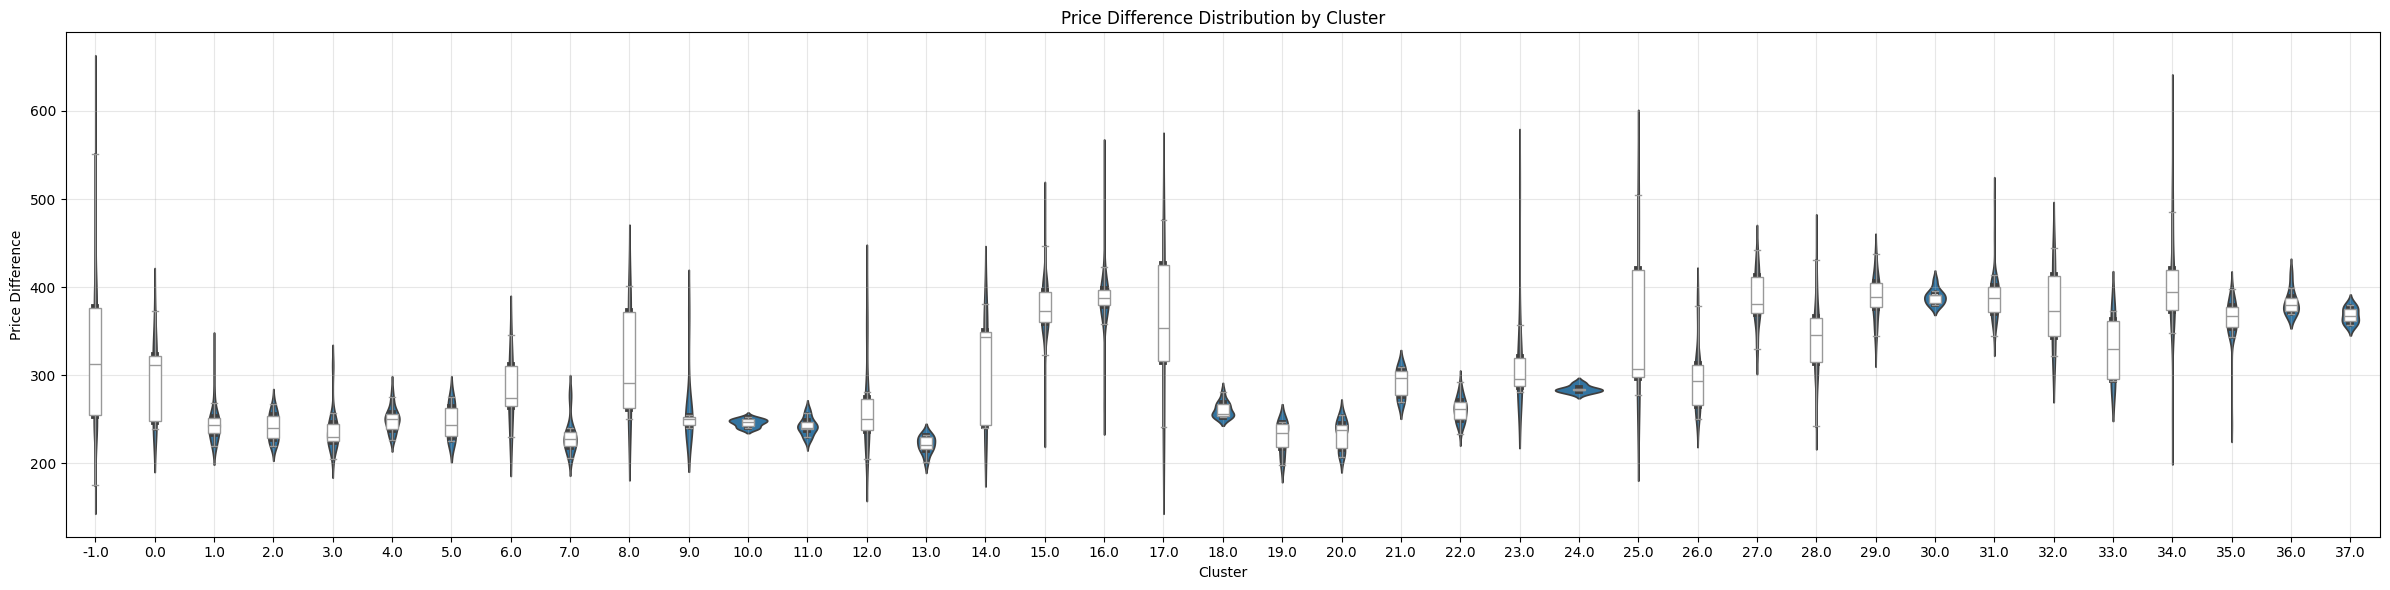


Cluster Statistics:
          count        mean        std         min         25%         50%  \
cluster                                                                      
-1.0     1520.0  319.998840  70.125999  175.250000  255.000000  312.619995   
 0.0       18.0  291.934998  43.481407  239.000000  248.205002  311.199997   
 1.0       30.0  245.718018  21.170439  220.000000  234.847496  243.949997   
 2.0       18.0  241.424973  14.725582  219.550003  228.615002  240.000000   
 3.0       37.0  237.209717  21.835215  205.000000  225.000000  230.000000   
 4.0       39.0  249.837158  13.666083  226.639999  239.470001  250.000000   
 5.0       10.0  247.114990  18.922224  225.339996  230.610001  243.769997   
 6.0       11.0  281.770905  35.749836  230.000000  264.955002  274.489990   
 7.0       27.0  230.901474  19.040874  205.710007  220.000000  227.350006   
 8.0       13.0  317.996155  58.183784  250.500000  262.670013  291.160004   
 9.0       10.0  260.044006  39.100990  240

In [48]:
start_train='20250720'
# end_train='20250729'
# start_date='20250815'
# start_date=today
end_date='20250914'
base_path = '/data/energy_market/grid_weather_dadi'
n=1

df=combine_shanxi_pkl_files(end_date, start_train, base_path='/data/energy_market/grid_weather_dadi',n=1)

# Run DBSCAN clustering
results = find_optimal_clusters_dbscan_improved(
    df, 
    save_plots=True,
    save_dir='./dbscan_results'
)

if results:
    print(f"Found {results['n_clusters']} clusters with {results['noise_ratio']:.1%} noise")
    print(f"Silhouette score: {results['silhouette_score']:.3f}")



prc_diff=ed.pull(['da', 'rt'], start=start_train, end=end_date)
prc_diff['diff']=prc_diff['da']

# prc_diff['diff']=prc_diff['da']-prc_diff['rt']
# solar=ed.pull(['solar_n1'], start=start_train, end=end_date)
cluster=results['clusters']
stats,df_with_clusters=plot_cluster_prc_distributions(prc_diff, cluster)

In [40]:
stats.sort_values('cluster').tail(39)


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
-1.0,1496.0,-16.619381,95.683357,-692.669983,-14.577507,1.519997,16.884998,363.000000
0.0,18.0,-29.773329,52.252457,-157.380005,-59.927490,-21.740005,13.920006,43.779999
1.0,30.0,4.210335,18.786272,-19.839996,-5.502506,3.905006,9.477505,72.520020
2.0,18.0,2.728332,11.410729,-14.190002,-7.832504,4.934998,11.227505,24.990005
3.0,37.0,9.227028,25.335661,-28.720001,1.389999,7.100006,11.869995,80.330002
4.0,39.0,-4.829231,16.470869,-50.769989,-17.634995,-3.550003,8.904999,23.089996
5.0,10.0,4.088004,14.064383,-20.120010,-4.992496,5.969994,14.490013,22.580017
6.0,11.0,37.583637,26.207005,0.600006,23.529999,31.119995,53.995010,92.669983
7.0,27.0,-20.112595,50.574459,-246.819992,-20.339989,-14.289993,-3.594994,51.789993


In [20]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import os

def find_optimal_clusters_fixed(df1, df2,wind_n1,solar_n1,gen_n1,system_n1,intertie_n1,selected_features=None, max_clusters=35, save_plots=True, save_dir=None):
    """
    Fixed version with proper plotting and debugging
    """
    # Set matplotlib backend for consistent plotting
    # if save_plots:
    #     matplotlib.use('TkAgg')  # Non-interactive backend
    
    # Create save directory
    if save_dir is None:
        save_dir = './clustering_results'
    os.makedirs(save_dir, exist_ok=True)
    
    print("Starting clustering analysis...")
    
    # Data preprocessing
    # Process first dataframe
    df1 = df1.drop(columns=['latitude', 'longitude', 'location_name', 'p10fg6'], errors='ignore')
    df1 = df1.rename(columns={col: f"{col}_1" for col in df1.columns})
    
    # Process second dataframe
    df2 = df2.drop(columns=['latitude', 'longitude', 'location_name', 'p10fg6'], errors='ignore')
    df2 = df2.rename(columns={col: f"{col}_2" for col in df2.columns})
    
    prefixes = [
       'd2m', 'skt', 'wbt', 'ws10m', 'ws100m', 'fg10', 'tcc', 
       'ssr', 'tp', 'rh', 'vpd', 'sp', 'ssrd', 'tcwv','v100'
    ]

    # Get weather features for both dataframes
    weather_features1 = [col for col in df1.columns if any(col.startswith(prefix) for prefix in prefixes)]
    weather_features2 = [col for col in df2.columns if any(col.startswith(prefix) for prefix in prefixes)]
    
    
    # Drop NaN values
    df1 = df1.dropna(subset=weather_features1)
    df2 = df2.dropna(subset=weather_features2)
    print(f"Data shape after dropping NaN - df1: {df1.shape}, df2: {df2.shape}")
    
    # Get weather features averages across locations for both dataframes
    df1_means = df1[weather_features1].groupby(df1.index).mean()
    df2_means = df2[weather_features2].groupby(df2.index).mean()
    
    # Merge the means from both dataframes
    # Use concat to merge the means from both dataframes
    # This works fine when they share the same column names
    df_means = pd.concat([df1_means, df2_means], axis=1, join='inner')
    print(df_means)
    # If there are duplicate indices, you might want to average them
    # Uncomment the next line if needed
    # df_means = df_means.groupby(level=0).mean()
    # df_means = pd.concat([df1_means, df2_means]).groupby(level=0).mean()

    print(f"Combined grouped data shape: {df_means.shape}")
    
    # Resample data to 30-minute intervals
    df_resampled = df_means.resample('15T').interpolate(method='linear')
    print(f"Resampled data shape: {df_resampled.shape}")

    # Ensure the index goes up to 23:30
    last_date = df_resampled.index[-1].date()
    expected_end = pd.Timestamp(f"{last_date} 23:45:00")

    if df_resampled.index[-1] != expected_end:
        new_index = pd.date_range(
            start=df_resampled.index[0],
            end=expected_end,
            freq='15T'
        )
        df_resampled = df_resampled.reindex(new_index)
        df_resampled = df_resampled.fillna(method='ffill')
    # ========================================================================================================================
    # Normalize or bin features to handle seasonal effects
    # Convert continuous weather features to quantile-based bins
    weather_features=weather_features1+weather_features2
    for feature in weather_features:
        if feature in df_resampled.columns:
            # Create 5 quantile bins for each weather feature
            df_resampled[feature] = pd.qcut(df_resampled[feature],5, labels=False, duplicates='drop')
            
    # Optionally create more descriptive bin categories for key features
    # for key_feature in ['d2m', 'skt', 'wbt']:
    #     if key_feature in df_resampled.columns:
    #         # Create descriptive temperature categories
    #         temp_bins = [-float('inf'), 0, 10, 20, 30, 40, float('inf')]
    #         temp_labels = ['freezing', 'cold', 'cool', 'mild', 'warm', 'hot']
    #         df_resampled[f'{key_feature}_cat'] = pd.cut(
    #             df_resampled[key_feature], bins=temp_bins, labels=temp_labels)
            
    print(f"Added quantile bins for weather features")
    # Normalize wind and solar generation by system load
    # Extract the values from the DataFrames to ensure proper assignment
    df_resampled['wind_n1'] = wind_n1['wind_n1']*5/ gen_n1['gen_n1']
    df_resampled['solar_n1'] = solar_n1['solar_n1'] *5/ gen_n1['gen_n1']
    df_resampled['system_n1'] = system_n1['system_n1']/6000
    df_resampled['intertie_n1'] = intertie_n1['intertie_n1']/2400
    # df_resampled['system_n1']=system_n1
    # Add time features
    df_resampled['hour'] = df_resampled.index.hour/6
    df_resampled['weekday'] = df_resampled.index.weekday/2
    df_resampled['is_weekend'] = (df_resampled.index.weekday >= 5).astype(int)
    df_resampled['time_of_day'] = df_resampled['hour'].apply(lambda x: 
    #     'midnight' if x < 3 or x >= 21 else                                           
    #     'dawn' if x < 9 else
    #     'morning' if x < 11 else
    #     'noon' if x < 13 else
    #     'afternoon' if x < 18 else
    #     'evening'
    # )
        'night' if x < 6 or x >= 22 else
        'morning' if x < 12 else
        'afternoon' if x < 18 else
        'evening'
    )
    
    # Map time_of_day to numeric values
    # time_map = { 'midnight': 0, 'dawn': 0,'morning': 1, 'noon': 1, 'afternoon': 1, 'evening': 2}
    time_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}

    df_resampled['time_of_day'] = df_resampled['time_of_day'].map(time_map)
    
    # Handle holiday calculation more robustly
    try:
        import calendar
        df_resampled['is_holiday'] = pd.Series(df_resampled.index.date).map(
            lambda d: int(calendar.is_holiday(d)) if hasattr(calendar, 'is_holiday') else 0
        ).values
    except:
        # Fallback: assume no holidays
        df_resampled['is_holiday'] = 0
        print("Warning: Holiday detection failed, using 0 for all dates")
    
    print(f"Final data shape with time features: {df_resampled.shape}")
    
    # Default features if none provided
    if selected_features is None:
        available_features = [
       'd2m_1', 'skt_1', 'v100_1',
    #    'wbt',
        #  'ws10m', 
         'ws100m_1', 'fg10_1', 
       'tcc_1', 
       'ssr_1', 'tp_1', 'rh_1', 
       'vpd_1', 
       'sp_1',
       'tcwv_1','wbt_1',
       
       'd2m_2', 'skt_2', 'v100_2',
         'ws100m_2', 'fg10_2', 
       'tcc_2', 
       'ssr_2', 'tp_2', 'rh_2', 
       'vpd_2', 
       'sp_2','tcwv_2','wbt_2',
    #    'fdir',
    #    'ssrd',
    #    'tcwv'
            # 'is_weekend',
            'weekday',
            #   'is_holiday', 
            # 'time_of_day', 
            'hour',
            'wind_n1','solar_n1','system_n1','intertie_n1'
        ]
        # Only use features that exist in the data
        selected_features = [f for f in available_features if f in df_resampled.columns]
    
    print(f"Selected features: {selected_features}")
    
    # Check if we have the selected features
    missing_features = [f for f in selected_features if f not in df_resampled.columns]
    if missing_features:
        print(f"Warning: Missing features: {missing_features}")
        selected_features = [f for f in selected_features if f in df_resampled.columns]
    
    if not selected_features:
        print("Error: No valid features found!")
        return None
    
    # Use the time points directly
    data = df_resampled[selected_features].copy()
    print(f"Clustering data shape: {data.shape}")
    
    # Check for any remaining NaN values
    nan_count = data.isna().sum().sum()
    if nan_count > 0:
        print(f"Warning: {nan_count} NaN values found, filling with forward fill")
        data = data.fillna(method='ffill').fillna(method='bfill')
    
    # Standardize features for clustering
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    print(f"Scaled data shape: {data_scaled.shape}")
    
    # Calculate inertia for different numbers of clusters
    print("Calculating optimal clusters...")
    inertias = []
    for k in range(20, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data_scaled)
        inertias.append(kmeans.inertia_)
        # if k % 5 == 0:
        #     print(f"Completed k={k}")
    
    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(range(20, max_clusters + 1), inertias, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True, alpha=0.3)
    
    if save_plots:
        elbow_path = os.path.join(save_dir, 'elbow_curve.png')
        plt.savefig(elbow_path, dpi=150, bbox_inches='tight')
        print(f"Elbow curve saved to: {elbow_path}")
        plt.close()
    else:
        plt.show()
    
    # Calculate elbow point using rate of change
    if len(inertias) > 2:
        inertia_changes = np.diff(inertias)
        rates_of_change = np.diff(inertia_changes)
        optimal_k = np.argmax(rates_of_change) + 20
    else:
        optimal_k = 3  # Default fallback
    
    print(f"Recommended number of clusters: {optimal_k}")
    
    # Perform clustering with optimal k
    print(f"Performing clustering with k={optimal_k}...")
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(data_scaled)
    
    clusters = pd.Series(
        cluster_labels,
        index=data.index,
        name='cluster'
    )
    
    print(f"Cluster distribution: {clusters.value_counts().sort_index()}")
    
    # Calculate cluster profiles
    cluster_profiles = data.groupby(clusters).mean()
    print("Cluster profiles calculated")
    
    # Perform t-SNE visualization
    print("Performing t-SNE analysis...")
    
    # Adjust perplexity based on data size
    n_samples = data_scaled.shape[0]
    perplexity = min(30, max(5, n_samples // 4))  # Adaptive perplexity
    
    try:
        tsne = TSNE(
            n_components=2, 
            random_state=42, 
            perplexity=perplexity,
            n_iter=1000,
            verbose=1  # Show progress
        )
        data_tsne = tsne.fit_transform(data_scaled)
        print("t-SNE completed successfully")
        
        # Create DataFrame for plotting
        tsne_df = pd.DataFrame(data_tsne, columns=['TSNE1', 'TSNE2'])
        tsne_df['Cluster'] = cluster_labels
        tsne_df.index = data.index  # Preserve original index
        
        print(f"t-SNE DataFrame shape: {tsne_df.shape}")
        print(f"t-SNE value ranges: TSNE1=({tsne_df['TSNE1'].min():.2f}, {tsne_df['TSNE1'].max():.2f}), "
              f"TSNE2=({tsne_df['TSNE2'].min():.2f}, {tsne_df['TSNE2'].max():.2f})")
        
        # Plot t-SNE results with improved visualization
        plt.figure(figsize=(12, 8))
        
        # Create scatter plot with different colors for each cluster
        unique_clusters = sorted(tsne_df['Cluster'].unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))
        
        for i, cluster in enumerate(unique_clusters):
            cluster_data = tsne_df[tsne_df['Cluster'] == cluster]
            plt.scatter(cluster_data['TSNE1'], cluster_data['TSNE2'], 
                       c=[colors[i]], label=f'Cluster {cluster}', 
                       alpha=0.7, s=50)
        
        plt.title(f't-SNE Visualization of Weather Clusters (k={optimal_k})')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # Add cluster centroids
        for cluster in unique_clusters:
            cluster_data = tsne_df[tsne_df['Cluster'] == cluster]
            centroid_x = cluster_data['TSNE1'].mean()
            centroid_y = cluster_data['TSNE2'].mean()
            plt.scatter(centroid_x, centroid_y, c='red', s=200, marker='x', linewidths=3)
        
        if save_plots:
            tsne_path = os.path.join(save_dir, 'tsne_visualization.png')
            plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
            print(f"t-SNE plot saved to: {tsne_path}")
            plt.close()
        else:
            plt.show()
        
        # Additional cluster analysis plot
        plt.figure(figsize=(15, 10))
        
        # Plot cluster profiles as heatmap
        import seaborn as sns
        sns.heatmap(cluster_profiles.T, annot=True, cmap='coolwarm', center=0)
        plt.title('Cluster Profiles Heatmap')
        plt.xlabel('Cluster')
        plt.ylabel('Features')
        
        if save_plots:
            heatmap_path = os.path.join(save_dir, 'cluster_profiles_heatmap.png')
            plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
            print(f"Cluster profiles heatmap saved to: {heatmap_path}")
            plt.close()
        else:
            plt.show()
            
    except Exception as e:
        print(f"Error during t-SNE: {e}")
        print(f"Data shape: {data_scaled.shape}, n_samples: {n_samples}, perplexity: {perplexity}")
        tsne_df = None

    print("Analysis completed!")
    
    return {
        'optimal_k': optimal_k,
        'clusters': clusters,
        'cluster_profiles': cluster_profiles,
        'tsne_data': tsne_df,
        'scaled_data': data_scaled,
        'feature_names': selected_features,
        'scaler': scaler
    }

# Usage example with debugging
def test_clustering(df):
    """
    Test function to debug clustering issues
    """
    print("Testing clustering function...")
    
    try:
        results = find_optimal_clusters_fixed(
            df, 
            max_clusters=35,  # Reduced for faster testing
            save_plots=True,
            save_dir='./test_clustering_results'
        )
        
        if results:
            print("✓ Clustering completed successfully")
            print(f"✓ Optimal clusters: {results['optimal_k']}")
            print(f"✓ Cluster distribution: {results['clusters'].value_counts()}")
            if results['tsne_data'] is not None:
                print("✓ t-SNE visualization completed")
            else:
                print("⚠ t-SNE failed")
        else:
            print("✗ Clustering failed")
            
    except Exception as e:
        print(f"✗ Error in clustering: {e}")
        import traceback
        traceback.print_exc()

def plot_cluster_prc_distributions(df, clusters):
    """
    Plot price difference distributions by cluster
    
    Parameters:
    -----------
    df : pandas DataFrame
    DataFrame containing price difference data
    clustering_results : dict
    Dictionary containing clustering results
    """   

    price_diff = df['diff']
    
    # Create a DataFrame with clusters and price differences
    df_with_clusters = pd.DataFrame({'prc_diff': price_diff})
    df_with_clusters['cluster'] = pd.Series(clusters, index=clusters.index)
    
    # Drop NaN values
    df_with_clusters = df_with_clusters.dropna()
    
    # Check if we have matching data
    if len(df_with_clusters) == 0:
        print("Error: No matching data between clusters and price differences")
        return None
    
    print(f"Data points with both cluster and price info: {len(df_with_clusters)}")
    print(df_with_clusters)
    # Create violin plot
    plt.figure(figsize=(24, 6))
    sns.violinplot(data=df_with_clusters, x='cluster', y='prc_diff')
    plt.title('Price Difference Distribution by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Price Difference')
    
    # Add box plot inside violin plot
    sns.boxplot(data=df_with_clusters, x='cluster', y='prc_diff', 
        width=0.2, color='white', showfliers=False)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nCluster Statistics:")
    stats = df_with_clusters.groupby('cluster')['prc_diff'].describe()
    print(stats)
    
    return stats,df_with_clusters
    # Call the function like this:
    # results = find_optimal_clusters_fixed(df, save_plots=True, save_dir='./my_results')
    # stats, df_with_clusters = plot_cluster_prc_distributions(prc_diff, cluster_results)

2025-09-23 14:04:38.262 | WARNING  | handler:wrapper:13 - wind_n1在20250819中存在部分nan值
2025-09-23 14:04:38.268 | WARNING  | handler:wrapper:13 - wind_n1在20250820中存在部分nan值
2025-09-23 14:04:38.275 | WARNING  | handler:wrapper:13 - wind_n1在20250821中存在部分nan值
2025-09-23 14:04:38.281 | WARNING  | handler:wrapper:13 - wind_n1在20250822中存在部分nan值
2025-09-23 14:04:38.287 | WARNING  | handler:wrapper:13 - wind_n1在20250823中存在部分nan值
2025-09-23 14:04:38.292 | WARNING  | handler:wrapper:13 - wind_n1在20250824中存在部分nan值
2025-09-23 14:04:38.296 | WARNING  | handler:wrapper:13 - wind_n1在20250825中存在部分nan值
2025-09-23 14:04:38.300 | WARNING  | handler:wrapper:13 - wind_n1在20250826中存在部分nan值
2025-09-23 14:04:38.304 | WARNING  | handler:wrapper:13 - wind_n1在20250827中存在部分nan值
2025-09-23 14:04:38.308 | WARNING  | handler:wrapper:13 - wind_n1在20250828中存在部分nan值
2025-09-23 14:04:38.311 | WARNING  | handler:wrapper:13 - wind_n1在20250829中存在部分nan值
2025-09-23 14:04:38.315 | WARNING  | handler:wrapper:13 - wind_n1在20250830中存

Starting clustering analysis...
Data shape after dropping NaN - df1: (47640, 40), df2: (42192, 40)
                        d2m_1      skt_1      wbt_1   ws10m_1    v100_1  \
timestamp                                                                 
2025-07-21 00:00:00  3.542703  13.414980  10.952846  3.440554  1.978569   
2025-07-21 01:00:00  3.826914  12.538591  10.712880  3.587826  2.697780   
2025-07-21 02:00:00  4.152903  11.889837  10.532920  3.565466  2.755286   
2025-07-21 03:00:00  4.165343  11.169249  10.227117  3.564783  2.716500   
2025-07-21 04:00:00  4.101194  10.528231   9.936637  3.533537  2.501314   
...                       ...        ...        ...       ...       ...   
2025-09-15 19:00:00 -3.085752   7.675590   6.309284  4.239181 -3.939271   
2025-09-15 20:00:00 -2.812568   6.390016   5.458865  3.380839 -3.873277   
2025-09-15 21:00:00 -2.766874   5.648223   4.972226  3.127329 -3.712274   
2025-09-15 22:00:00 -2.686252   4.914642   4.527500  2.931229 -3.494081   
2

/home/wyj/anaconda3/envs/myenvtorchpy3.9/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed conditional probabilities for sample 2000 / 5472
[t-SNE] Computed conditional probabilities for sample 3000 / 5472
[t-SNE] Computed conditional probabilities for sample 4000 / 5472
[t-SNE] Computed conditional probabilities for sample 5000 / 5472
[t-SNE] Computed conditional probabilities for sample 5472 / 5472
[t-SNE] Mean sigma: 1.683944
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.491524
[t-SNE] KL divergence after 1000 iterations: 0.472778
t-SNE completed successfully
t-SNE DataFrame shape: (5472, 3)
t-SNE value ranges: TSNE1=(-74.62, 92.07), TSNE2=(-83.63, 75.79)
t-SNE plot saved to: ./clustering_results/tsne_visualization.png
Cluster profiles heatmap saved to: ./clustering_results/cluster_profiles_heatmap.png
Analysis completed!
Data points with both cluster and price info: 5472
                       prc_diff  cluster
2025-07-21 00:00:00  190.000000        2
2025-07-21 00:15:00  160.000000        2
2025-07-21 00:30:00  180.000000       

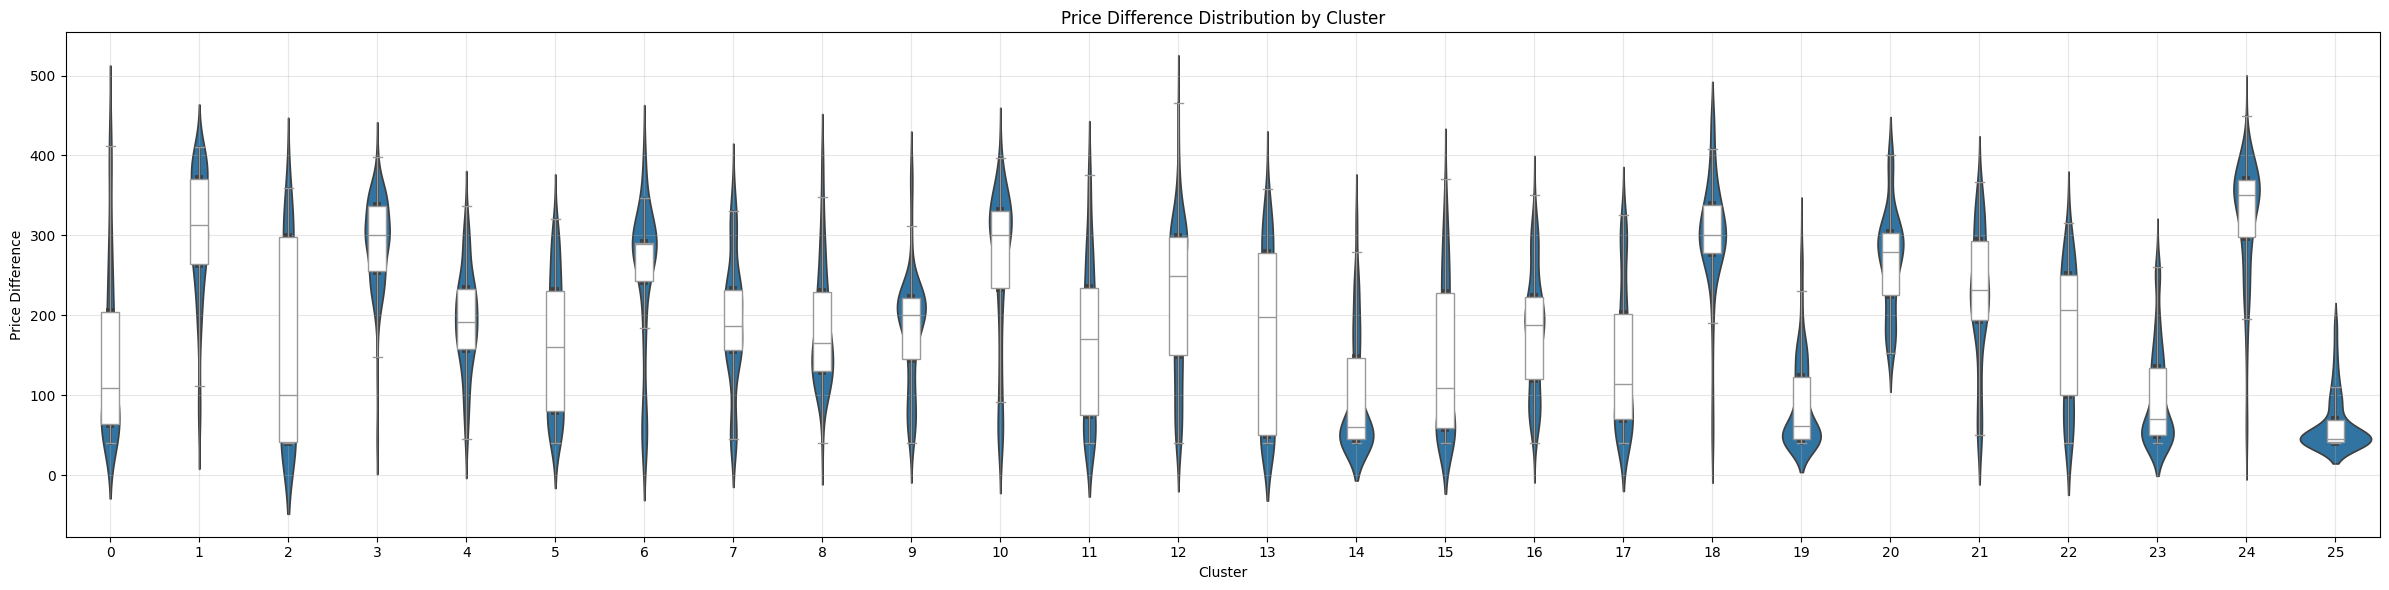


Cluster Statistics:
         count        mean         std         min         25%         50%  \
cluster                                                                      
0        241.0  147.186859  103.713768   40.110001   63.970001  109.010002   
1        205.0  304.072083   77.974556   61.520000  264.190002  313.450012   
2        163.0  163.526978  122.468132   40.000000   41.025000  100.000000   
3        131.0  289.483429   58.215012   45.020000  255.005005  300.000000   
4        189.0  193.604492   62.772343   40.230000  157.179993  191.139999   
5        250.0  160.020691   84.978561   40.150002   80.000000  160.000000   
6        117.0  251.004211   92.470665   40.000000  242.559998  289.049988   
7        204.0  192.211609   79.390610   40.000000  157.077496  185.975006   
8        184.0  184.110062   73.664871   40.180000  130.677498  165.794998   
9        187.0  183.555237   70.305756   40.000000  144.745003  199.910004   
10       283.0  263.560303   96.934486   40

In [21]:
start_train='20250720'
start_train_1='20250721'

end_date='20250914'
end_date_1='20250915'

base_path = '/data/energy_market/grid_weather_dadi'
n=1
df_south=combine_shanxi_pkl_files_south(end_date, start_train, base_path='/data/energy_market/grid_weather_dadi',n=1)
df_north=combine_shanxi_pkl_files_north(end_date, start_train, base_path='/data/energy_market/grid_weather_dadi',n=1)   
wind_n1=ed.pull(['wind_n1'], start=start_train_1, end=end_date_1)
solar_n1=ed.pull(['solar_n1'], start=start_train_1, end=end_date_1)
gen_n1=ed.pull(['gen_n1'], start=start_train_1, end=end_date_1)
system_n1=ed.pull(['system_n1'], start=start_train_1, end=end_date_1)
intertie_n1=ed.pull(['intertie_n1'], start=start_train_1, end=end_date_1)
cluster_results = find_optimal_clusters_fixed(df_south, df_north,wind_n1,solar_n1,gen_n1,system_n1, intertie_n1 ) #change province   




prc_diff=ed.pull(['da', 'rt'], start=start_train_1, end=end_date_1)
# prc_diff['diff']=prc_diff['rt']
prc_diff['diff']=prc_diff['da']

# prc_diff['diff']=prc_diff['da']-prc_diff['rt']
# solar=ed.pull(['solar_n1'], start=start_train, end=end_date)
cluster=cluster_results['clusters']
stats,df_with_clusters=plot_cluster_prc_distributions(prc_diff, cluster)

In [91]:
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

def assign_to_closest_cluster(clustering_results, selected_features=None):

    df_s=combine_shanxi_pkl_files_south('20250916', '20250915', base_path='/data/energy_market/grid_weather_dadi',n=1)
    df_n=combine_shanxi_pkl_files_north('20250916', '20250915', base_path='/data/energy_market/grid_weather_dadi',n=1)   
    wind_n1 = ed.pull(['wind_n1'], start='20250916', end='20250917')
    solar_n1 = ed.pull(['solar_n1'], start='20250916', end='20250917')
    gen_n1=ed.pull(['gen_n1'], start='20250916', end='20250917')
    system_n1=ed.pull(['system_n1'], start='20250916', end='20250917')
      
    # Data preprocessing
    # Process first dataframe
    df1 = df_s.drop(columns=['latitude', 'longitude', 'location_name', 'p10fg6'], errors='ignore')
    df1 = df1.rename(columns={col: f"{col}_1" for col in df1.columns})
    
    # Process second dataframe
    df2 = df_n.drop(columns=['latitude', 'longitude', 'location_name', 'p10fg6'], errors='ignore')
    df2 = df2.rename(columns={col: f"{col}_2" for col in df2.columns})
    
    prefixes = [
       'd2m', 'skt', 'wbt', 'ws10m', 'ws100m', 'fg10', 'tcc', 
       'ssr', 'tp', 'rh', 'vpd', 'sp', 'ssrd', 'tcwv','v100'
    ]

    # Get weather features for both dataframes
    weather_features1 = [col for col in df1.columns if any(col.startswith(prefix) for prefix in prefixes)]
    weather_features2 = [col for col in df2.columns if any(col.startswith(prefix) for prefix in prefixes)]
    
    # Drop NaN values
    df1 = df1.dropna(subset=weather_features1)
    df2 = df2.dropna(subset=weather_features2)
    print(f"Data shape after dropping NaN - df1: {df1.shape}, df2: {df2.shape}")
    
    # Get weather features averages across locations for both dataframes
    df1_means = df1[weather_features1].groupby(df1.index).mean()
    df2_means = df2[weather_features2].groupby(df2.index).mean()
    
    # Merge the means from both dataframes
    df_means = pd.concat([df1_means, df2_means], axis=1, join='inner')
    print(df_means)

    print(f"Combined grouped data shape: {df_means.shape}")
    
    # Resample data to 15-minute intervals
    df_resampled = df_means.resample('15T').interpolate(method='linear')
    print(f"Resampled data shape: {df_resampled.shape}")

    # Ensure the index goes up to 23:45
    last_date = df_resampled.index[-1].date()
    expected_end = pd.Timestamp(f"{last_date} 23:45:00")

    if df_resampled.index[-1] != expected_end:
        new_index = pd.date_range(
            start=df_resampled.index[0],
            end=expected_end,
            freq='15T'
        )
        df_resampled = df_resampled.reindex(new_index)
        df_resampled = df_resampled.fillna(method='ffill')
        
    # Normalize or bin features to handle seasonal effects
    weather_features=weather_features1+weather_features2
    for feature in weather_features:
        if feature in df_resampled.columns:
            # Create 5 quantile bins for each weather feature
            df_resampled[feature] = pd.qcut(df_resampled[feature],5, labels=False, duplicates='drop')
            
    print(f"Added quantile bins for weather features")
    
    # Normalize wind and solar generation by system load
    df_resampled['wind_n1'] = wind_n1['wind_n1']*4/ gen_n1['gen_n1']
    df_resampled['solar_n1'] = solar_n1['solar_n1'] *4/ gen_n1['gen_n1']
    df_resampled['system_n1'] = system_n1['system_n1']/7000
    
    # Add time features
    df_resampled['hour'] = df_resampled.index.hour/6
    df_resampled['is_weekend'] = (df_resampled.index.weekday >= 5).astype(int)
    df_resampled['time_of_day'] = df_resampled['hour'].apply(lambda x: 
        'night' if x < 6 or x >= 22 else
        'morning' if x < 12 else
        'afternoon' if x < 18 else
        'evening'
    )
    
    # Map time_of_day to numeric values
    time_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}

    df_resampled['time_of_day'] = df_resampled['time_of_day'].map(time_map)
    
    # Handle holiday calculation more robustly
    try:
        import calendar
        df_resampled['is_holiday'] = pd.Series(df_resampled.index.date).map(
            lambda d: int(calendar.is_holiday(d)) if hasattr(calendar, 'is_holiday') else 0
        ).values
    except:
        # Fallback: assume no holidays
        df_resampled['is_holiday'] = 0
        print("Warning: Holiday detection failed, using 0 for all dates")
    
    print(f"Final data shape with time features: {df_resampled.shape}")
    
    # Default features if none provided
    if selected_features is None:
        available_features = [
           'd2m_1', 'skt_1', 'v100_1',
           'ws100m_1', 'fg10_1', 'tcc_1', 
           'ssr_1', 'tp_1', 'rh_1', 'vpd_1', 'sp_1',
           'd2m_2', 'skt_2', 'v100_2',
           'ws100m_2', 'fg10_2', 'tcc_2', 
           'ssr_2', 'tp_2', 'rh_2', 'vpd_2', 'sp_2',
           'is_weekend', 'hour',
           'wind_n1', 'solar_n1', 'system_n1'
        ]
        # Only use features that exist in the data
        selected_features = [f for f in available_features if f in df_resampled.columns]

    data = df_resampled[selected_features].copy()

    # prc_diff=ed.pull(['da', 'rt'], start='20250916', end='20250916')
    
    # Fill NaN values
    data = data.fillna(method='ffill').fillna(method='bfill')
    
    # Calculate distances to cluster centers
    # For KMeans clustering
    if 'optimal_k' in clustering_results:
        # Fix: Use the stored cluster profiles directly for prediction
        centers = clustering_results['cluster_profiles'].values
        
        # # Apply the same scaling as was used during training if scaler exists
        # if 'scaler' in clustering_results:
        #     scaler = clustering_results['scaler']
        #     data_scaled = scaler.transform(data)
        # else:
        data_scaled = data.values
            
        # Compute distances to each cluster center
        distances = np.sqrt(((data_scaled[:, np.newaxis, :] - centers) ** 2).sum(axis=2))
        
        # Assign points to nearest cluster
        cluster_assignments = np.argmin(distances, axis=1)
    
    # If it's DBSCAN clustering, we need a different approach
    elif 'optimal_eps' in clustering_results:
        # Get all data points with their cluster labels
        all_data = clustering_results['scaled_data']
        all_labels = clustering_results['clusters'].values
        
        # For each new point, find the nearest neighbor in the original data
        knn = NearestNeighbors(n_neighbors=1)
        knn.fit(all_data)
        
        # Find the nearest neighbors
        distances, indices = knn.kneighbors(data)
        
        # Assign the cluster of the nearest neighbor
        cluster_assignments = all_labels[indices.flatten()]
    
    else:
        raise ValueError("Unknown clustering method in clustering_results")
    
    # Return as a Series with the same index as the input data
    return pd.Series(cluster_assignments, index=data.index)


In [92]:
solar_n1=ed.pull(['solar_n1'], start='20250916', end='20250917')


2025-09-17 17:16:19.628 | WARNING  | handler:wrapper:13 - solar_n1在20250916中存在部分nan值
2025-09-17 17:16:19.634 | WARNING  | handler:wrapper:13 - solar_n1在20250917中存在部分nan值


In [84]:
solar_n1


,solar_n1
2025-09-16 00:00:00,0.0
2025-09-16 00:15:00,0.0
2025-09-16 00:30:00,0.0
2025-09-16 00:45:00,0.0
2025-09-16 01:00:00,0.0
...,...
2025-09-17 22:45:00,0.0
2025-09-17 23:00:00,0.0
2025-09-17 23:15:00,0.0
2025-09-17 23:30:00,0.0


In [93]:
clustering_results=cluster_results
assign=assign_to_closest_cluster(clustering_results, selected_features=None)


2025-09-17 17:16:24.693 | WARNING  | handler:wrapper:13 - wind_n1在20250916中存在部分nan值
2025-09-17 17:16:24.698 | WARNING  | handler:wrapper:13 - wind_n1在20250917中存在部分nan值
2025-09-17 17:16:24.702 | WARNING  | handler:wrapper:13 - solar_n1在20250916中存在部分nan值
2025-09-17 17:16:24.705 | WARNING  | handler:wrapper:13 - solar_n1在20250917中存在部分nan值
2025-09-17 17:16:24.714 | WARNING  | handler:wrapper:13 - system_n1在20250916中存在部分nan值
2025-09-17 17:16:24.717 | WARNING  | handler:wrapper:13 - system_n1在20250917中存在部分nan值


Data shape after dropping NaN - df1: (1680, 40), df2: (1440, 40)
                        d2m_1     skt_1     wbt_1   ws10m_1    v100_1  \
timestamp                                                               
2025-09-16 00:00:00 -1.573977  3.404240  4.122860  3.057046 -2.860889   
2025-09-16 01:00:00 -1.785683  2.800046  3.744491  3.138771 -2.675386   
2025-09-16 02:00:00 -2.074191  2.211054  3.352280  3.227914 -2.570251   
2025-09-16 03:00:00 -2.274391  1.765374  3.042291  3.166771 -2.306591   
2025-09-16 04:00:00 -2.365637  1.352329  2.773706  3.088846 -2.035260   
2025-09-16 05:00:00 -2.370906  0.933509  2.554591  3.068686 -2.139069   
2025-09-16 06:00:00 -2.334534  0.571343  2.365651  3.042160 -2.133777   
2025-09-16 07:00:00 -2.317377  0.231443  2.201374  3.097100 -2.096971   
2025-09-16 08:00:00 -2.156329  0.616857  2.529260  3.247737 -1.959271   
2025-09-16 09:00:00 -1.940300  2.254620  3.577194  3.339246 -1.787517   
2025-09-16 10:00:00 -2.015671  3.665326  4.521749  3.939286

In [95]:

w=ed.pull(['da', 'rt'], start='20250916', end='20250917')
# prc_diff['diff']=prc_diff['rt']
# prc_diff['diff']=prc_diff['da']


2025-09-17 17:16:32.987 | WARNING  | EnergyDataLoader.energydataloader:read_row:47 - rt在20250916的文件不存在
2025-09-17 17:16:32.993 | WARNING  | EnergyDataLoader.energydataloader:read_row:47 - rt在20250917的文件不存在


In [78]:
w

,da,rt
2025-09-17 00:00:00,79.230003,NaN
2025-09-17 00:15:00,78.790001,NaN
2025-09-17 00:30:00,80.550003,NaN
2025-09-17 00:45:00,81.809998,NaN
2025-09-17 01:00:00,83.040001,NaN
...,...,...
2025-09-17 22:45:00,124.290001,NaN
2025-09-17 23:00:00,90.779999,NaN
2025-09-17 23:15:00,87.040001,NaN
2025-09-17 23:30:00,87.360001,NaN


In [96]:
# Group by clusters and calculate mean and median for 'da' and 'rt'
cluster_stats = prc_diff.groupby(cluster).agg({
    'da': ['mean', 'median'],
    'rt': ['mean', 'median']
})

# Rename columns for clarity
cluster_stats.columns = ['da_mean', 'da_median', 'rt_mean', 'rt_median']

print(cluster_stats)

            da_mean   da_median     rt_mean   rt_median
cluster                                                
0        203.780792  221.630005  204.173889  213.699997
1        102.048897   70.680000  125.296539  159.250000
2        231.208664  250.309998  263.173431  272.720001
3        279.602173  298.270020  315.049469  320.000000
4        235.718475  277.869995  230.647705  270.000000
5        215.297440  212.095001  232.996017  213.885010
6        253.671570  300.000000  226.574158  280.239990
7        218.636597  229.589996  260.423157  255.289993
8        197.972488  194.460007  230.425629  233.210007
9        143.584320  114.949997  150.552383  149.259995
10       139.765656  127.864998  149.961792  173.535004
11        60.995499   45.180000   56.544384   40.000000
12       131.145264  110.919998  116.689713   80.000000
13       147.851761  100.000000  161.396011   40.000000
14        86.108856   60.110001   81.258858   40.000000
15       289.536072  298.000000  286.137482  304

In [102]:
# Look up cluster stats for each predicted cluster assignment
cluster_stats_aligned = cluster_stats.loc[assign.unique()]

print("Predicted cluster statistics for 2025-09-16:")
print(cluster_stats_aligned)

# Map each cluster assignment to its DA mean price
price_predictions = pd.Series(index=assign.index)
for cluster_id in assign.unique():
    mask = assign == cluster_id
    price_predictions[mask] = cluster_stats.loc[cluster_id,'da_mean']

print("\nPrice predictions for 2025-09-16 based on weather clusters:")
print(price_predictions)

# Compare with actual prices for that day
print("\nComparison with actual prices:")
comparison = pd.DataFrame({
    'predicted_da': price_predictions,
    'actual_da': w['da']
})
comparison['error'] = comparison['actual_da'] - comparison['predicted_da']
print(comparison.head(10))
print("\nMean absolute error:", abs(comparison['error']).mean())

Predicted cluster statistics for 2025-09-16:
            da_mean   da_median     rt_mean   rt_median
cluster                                                
8        197.972488  194.460007  230.425629  233.210007
16       286.610657  306.145020  287.534058  331.635010
5        215.297440  212.095001  232.996017  213.885010
18       179.456451  196.440002  173.353897  184.869995
20       172.748184  171.815002  159.535873  168.289993
2        231.208664  250.309998  263.173431  272.720001
15       289.536072  298.000000  286.137482  304.880005
1        102.048897   70.680000  125.296539  159.250000
4        235.718475  277.869995  230.647705  270.000000
6        253.671570  300.000000  226.574158  280.239990
13       147.851761  100.000000  161.396011   40.000000
9        143.584320  114.949997  150.552383  149.259995
14        86.108856   60.110001   81.258858   40.000000
19        96.411758   61.695000  112.442406   40.000000
7        218.636597  229.589996  260.423157  255.289993

Pr

In [111]:
comparison

,predicted_da,actual_da,error
2025-09-16 00:00:00,197.972488,86.959999,-111.012489
2025-09-16 00:15:00,197.972488,107.739998,-90.232491
2025-09-16 00:30:00,197.972488,104.739998,-93.232491
2025-09-16 00:45:00,197.972488,93.889999,-104.082489
2025-09-16 01:00:00,197.972488,81.910004,-116.062485
...,...,...,...
2025-09-17 22:45:00,102.048897,124.290001,22.241104
2025-09-17 23:00:00,102.048897,90.779999,-11.268898
2025-09-17 23:15:00,102.048897,87.040001,-15.008896
2025-09-17 23:30:00,102.048897,87.360001,-14.688896


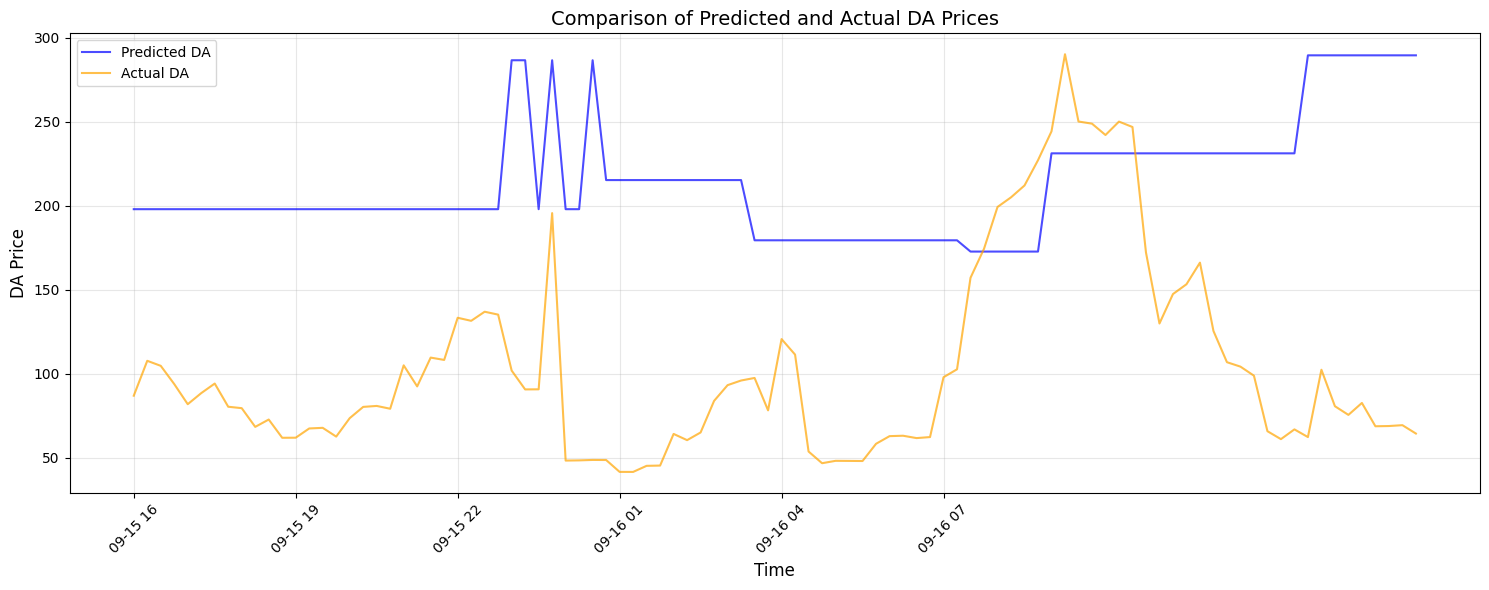

In [119]:
import matplotlib.pyplot as plt

# Plot the predicted and actual prices
plt.figure(figsize=(15, 6))
plt.plot(comparison[:96].index, comparison['predicted_da'][:96], label='Predicted DA', color='blue', alpha=0.7)
plt.plot(comparison[:96].index, comparison['actual_da'][:96], label='Actual DA', color='orange', alpha=0.7)

# Add labels, title, and legend
plt.title('Comparison of Predicted and Actual DA Prices', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('DA Price', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

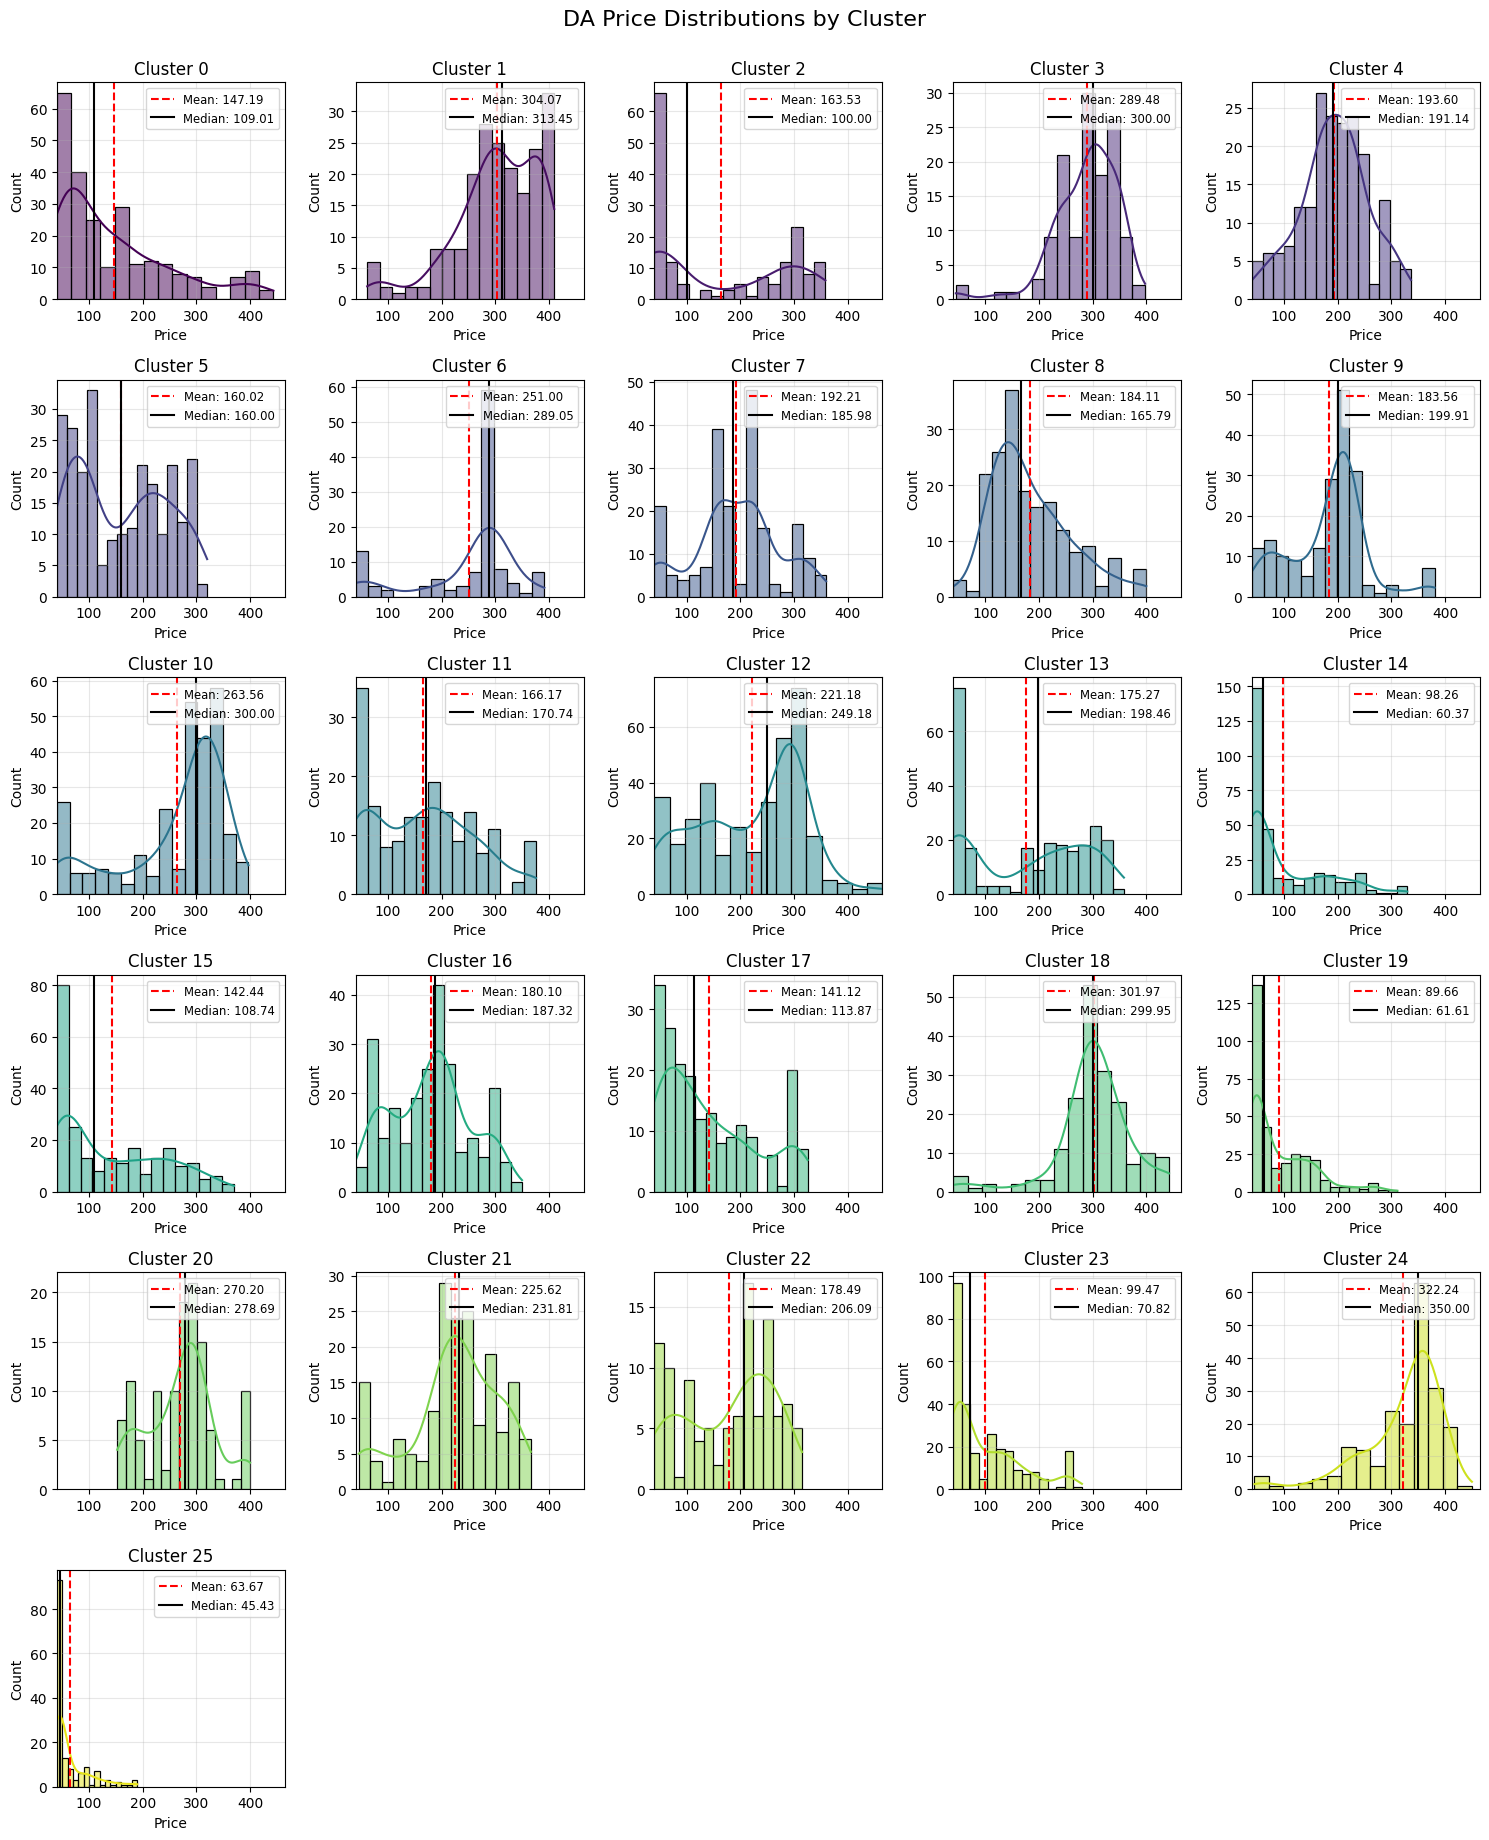

现货Price Statistics by Cluster:
         count        mean         std         min         25%         50%  \
cluster                                                                      
0          241  147.186859  103.713762   40.110001   63.970001  109.010002   
1          205  304.072113   77.974551   61.520000  264.190002  313.450012   
2          163  163.526993  122.468116   40.000000   41.025000  100.000000   
3          131  289.483429   58.215012   45.020000  255.005005  300.000000   
4          189  193.604492   62.772337   40.230000  157.179993  191.139999   
5          250  160.020691   84.978559   40.150002   80.000000  160.000000   
6          117  251.004196   92.470663   40.000000  242.559998  289.049988   
7          204  192.211609   79.390607   40.000000  157.077496  185.975006   
8          184  184.110062   73.664873   40.180000  130.677498  165.794998   
9          187  183.555237   70.305747   40.000000  144.745003  199.910004   
10         283  263.560303   96.9

In [22]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Set up a multi-panel figure for the histograms
unique_clusters = sorted(df_with_clusters['cluster'].unique())
n_clusters = len(unique_clusters)

# Calculate number of rows and columns for subplot grid
n_cols = min(5, n_clusters)
n_rows = int(np.ceil(n_clusters / n_cols))

plt.figure(figsize=(15, 3*n_rows))

# Create histograms for each cluster
for i, cluster_id in enumerate(unique_clusters):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster_id]['prc_diff']
    
    plt.subplot(n_rows, n_cols, i+1)
    
    # Add histograms with KDE overlay
    sns.histplot(cluster_data, kde=True, bins=15, color=plt.cm.viridis(i/n_clusters))
    
    # Add vertical line for mean
    plt.axvline(x=cluster_data.mean(), color='red', linestyle='--', 
                label=f'Mean: {cluster_data.mean():.2f}')
    
    # Add vertical line for median
    plt.axvline(x=cluster_data.median(), color='black', linestyle='-', 
                label=f'Median: {cluster_data.median():.2f}')
    
    plt.title(f'Cluster {int(cluster_id)}')
    plt.xlabel('Price')
    
    # Set consistent x-axis limits based on data range with some padding
    all_data_min = df_with_clusters['prc_diff'].min()
    all_data_max = df_with_clusters['prc_diff'].max()
    # plt.xlim(max(all_data_min, -200), min(all_data_max, 200))
    plt.xlim(all_data_min, all_data_max)

    
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('DA Price Distributions by Cluster', y=1.02, fontsize=16)
plt.show()

# Summary statistics table with additional metrics
summary_stats = df_with_clusters.groupby('cluster')['prc_diff'].agg([
    'count',
    'mean', 
    'std', 
    'min', 
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max',
    lambda x: (x > 0).mean() * 100  # Percentage of positive price differences
]).rename(columns={
    '<lambda_0>': '25%',
    'median': '50%',
    '<lambda_1>': '75%',
    '<lambda_2>': 'pos_pct'
})

print("现货Price Statistics by Cluster:")
print(summary_stats)

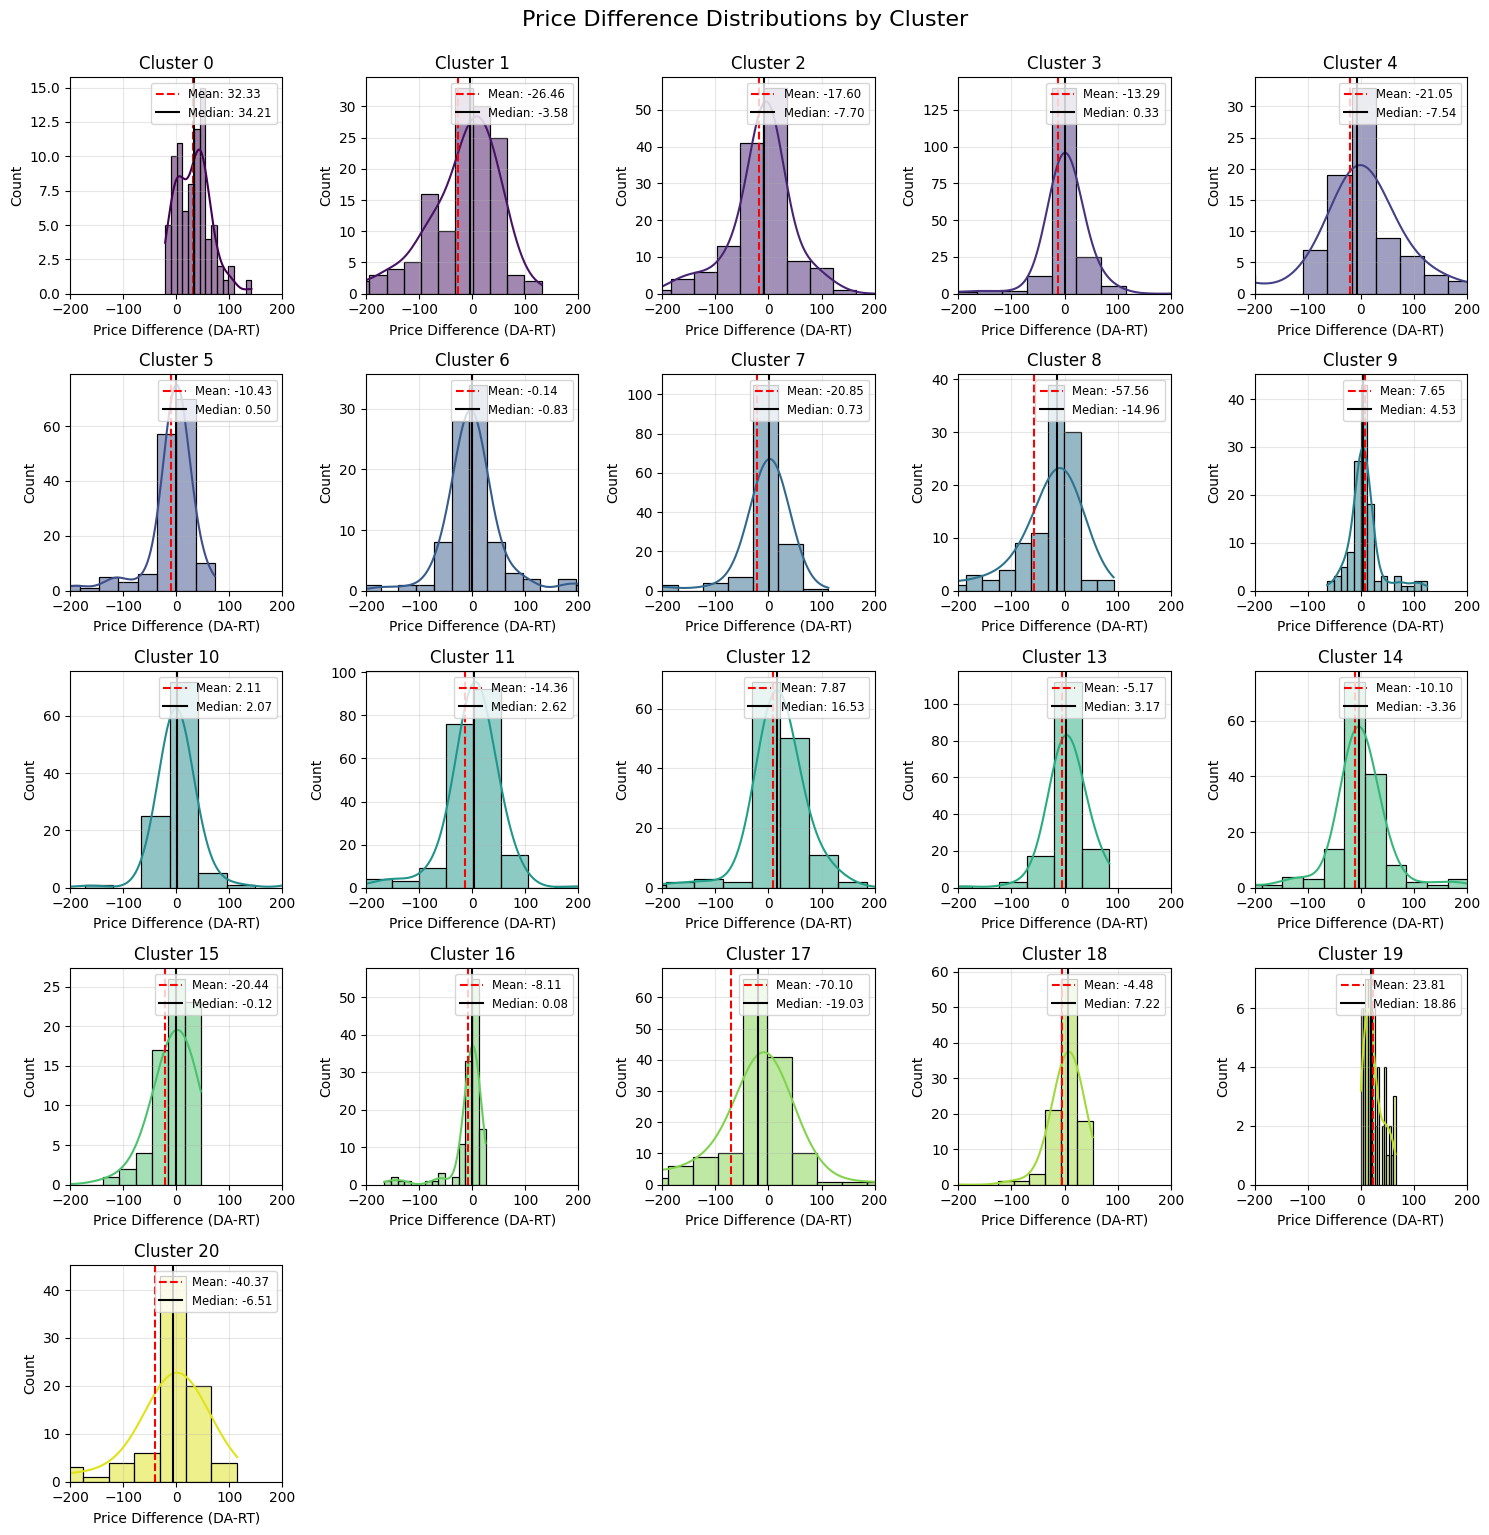

Price Difference Statistics by Cluster:
         count       mean         std         min         25%        50%  \
cluster                                                                    
0.0         82  32.326584   31.900358  -20.869995    3.719994  34.214996   
1.0        138 -26.457535   82.960089 -356.160034  -65.082512  -3.584991   
2.0        142 -17.603804   76.532571 -358.899994  -28.550003  -7.700012   
3.0        197 -13.286853   81.810898 -444.950012  -12.839996   0.330002   
4.0         92 -21.051739  122.496986 -426.029968  -28.902485  -7.544998   
5.0        155 -10.432580   56.129247 -472.169983  -15.044998   0.500000   
6.0         90  -0.136333   61.279499 -272.889984  -18.559998  -0.834991   
7.0        150 -20.845997   92.679313 -594.819946  -11.615005   0.729996   
8.0        117 -57.561707  103.704418 -371.859985  -67.029999 -14.959991   
9.0        120   7.650084   31.198457  -63.099991   -5.142502   4.529999   
10.0       109   2.108991   73.996369 -440.29995

In [46]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Set up a multi-panel figure for the histograms
unique_clusters = sorted(df_with_clusters['cluster'].unique())
n_clusters = len(unique_clusters)

# Calculate number of rows and columns for subplot grid
n_cols = min(5, n_clusters)
n_rows = int(np.ceil(n_clusters / n_cols))

plt.figure(figsize=(15, 3*n_rows))

# Create histograms for each cluster
for i, cluster_id in enumerate(unique_clusters):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster_id]['prc_diff']
    
    plt.subplot(n_rows, n_cols, i+1)
    
    # Add histograms with KDE overlay
    sns.histplot(cluster_data, kde=True, bins=15, color=plt.cm.viridis(i/n_clusters))
    
    # Add vertical line for mean
    plt.axvline(x=cluster_data.mean(), color='red', linestyle='--', 
                label=f'Mean: {cluster_data.mean():.2f}')
    
    # Add vertical line for median
    plt.axvline(x=cluster_data.median(), color='black', linestyle='-', 
                label=f'Median: {cluster_data.median():.2f}')
    
    plt.title(f'Cluster {int(cluster_id)}')
    plt.xlabel('Price Difference (DA-RT)')
    
    # Set consistent x-axis limits based on data range with some padding
    all_data_min = df_with_clusters['prc_diff'].min()
    all_data_max = df_with_clusters['prc_diff'].max()
    plt.xlim(max(all_data_min, -200), min(all_data_max, 200))
    # plt.xlim(all_data_min, all_data_max,)

    
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Price Difference Distributions by Cluster', y=1.02, fontsize=16)
plt.show()

# Summary statistics table with additional metrics
summary_stats = df_with_clusters.groupby('cluster')['prc_diff'].agg([
    'count',
    'mean', 
    'std', 
    'min', 
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max',
    lambda x: (x > 0).mean() * 100  # Percentage of positive price differences
]).rename(columns={
    '<lambda_0>': '25%',
    'median': '50%',
    '<lambda_1>': '75%',
    '<lambda_2>': 'pos_pct'
})

print("Price Difference Statistics by Cluster:")
print(summary_stats)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import numpy as np

def find_optimal_clusters(df, selected_features=None, max_clusters=35):
    df = df.drop(columns=['latitude', 'longitude','location_name','p10fg6'])

    prefixes = [
       'd2m', 'skt', 
       'wbt', 
       'ws10m', 
       'ws100m', 
       'fg10', 
       'tcc',  'hcc', 
       'ssr',
       'tp',
       'rh', 
       'vpd'
    ]

    weather_features = [col for col in df.columns if any(col.startswith(prefix) for prefix in prefixes)]
    df = df.dropna(subset=weather_features)
    
    # Get weather features averages across locations
    df_means = df[weather_features].groupby(df.index).mean()
    # Resample data to 30-minute intervals using interpolation
    df_resampled = df_means.resample('30T').interpolate(method='linear')

    # Ensure the index goes up to 23:30
    last_date = df_resampled.index[-1].date()
    expected_end = pd.Timestamp(f"{last_date} 23:30:00")

    if df_resampled.index[-1] != expected_end:
        new_index = pd.date_range(
            start=df_resampled.index[0],
            end=expected_end,
            freq='30T'
        )
        df_resampled = df_resampled.reindex(new_index)
        # Forward fill any missing values
        df_resampled = df_resampled.fillna(method='ffill')

    # Add time features
    df_resampled['hour'] = df_resampled.index.hour
    df_resampled['is_weekend'] = (df_resampled.index.weekday >= 5).astype(int)
    df_resampled['time_of_day'] = df_resampled['hour'].apply(lambda x: 
        'night' if x < 6 or x >= 22 else
        'morning' if x < 12 else
        'afternoon' if x < 18 else
        'evening'
    )
    # Map time_of_day to numeric values
    time_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}
    df_resampled['time_of_day'] = df_resampled['time_of_day'].map(time_map)
    df_resampled['is_holiday'] = pd.Series(df_resampled.index.date).map(lambda d: int(calendar.is_holiday(d))).values
    print(df_resampled)
    
    df_means = df_resampled
    # Default features if none provided
    if selected_features is None:
        selected_features = [
            'ws100m',  # wind speed
            'fg10',    # 10m wind gust
            'rh',      # relative humidity 
            'tcc',     # total cloud cover
            'tp',      # total precipitation
            'vpd',     # vapor pressure deficit
            'is_weekend',
            'is_holiday',
            'time_of_day',
            'd2m',    # 2m dew point temperature
            'skt',    # skin temperature
            'wbt'     # wet-bulb temperature

        ]
    
    # Use the time points directly instead of daily means
    data = df_means[selected_features]
    
    # Standardize features for clustering
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # Calculate inertia for different numbers of clusters
    inertias = []
    for k in range(10, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data_scaled)
        inertias.append(kmeans.inertia_)
    
    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(range(10, max_clusters + 1), inertias, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()
    
    # Calculate elbow point using rate of change
    inertia_changes = np.diff(inertias)
    rates_of_change = np.diff(inertia_changes)
    optimal_k = np.argmax(rates_of_change) + 10
    
    print(f"Recommended number of clusters: {optimal_k}")
    
    # Perform clustering with optimal k
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    clusters = pd.Series(
        kmeans.fit_predict(data_scaled),
        index=data.index,
        name='cluster'
    )

    # Calculate cluster profiles
    cluster_profiles = data.groupby(clusters).mean()
    
    # Perform t-SNE visualization of clusters
    tsne = TSNE(n_components=2, random_state=42)
    data_tsne = tsne.fit_transform(data_scaled)

    # Create DataFrame for plotting
    tsne_df = pd.DataFrame(data_tsne, columns=['TSNE1', 'TSNE2'])
    tsne_df['Cluster'] = clusters

    # Plot t-SNE results
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], 
                         c=tsne_df['Cluster'], cmap='viridis')
    plt.title('t-SNE Visualization of Weather Clusters')
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()

    return {
        'optimal_k': optimal_k,
        'clusters': clusters,
        'cluster_profiles': cluster_profiles
    }


In [9]:
cluster_results['clusters']

2025-07-02 00:00:00    16
2025-07-02 00:30:00    16
2025-07-02 01:00:00    16
2025-07-02 01:30:00    16
2025-07-02 02:00:00    16
                       ..
2025-09-11 21:30:00    18
2025-09-11 22:00:00     6
2025-09-11 22:30:00     6
2025-09-11 23:00:00     6
2025-09-11 23:30:00     6
Freq: 30T, Name: cluster, Length: 3456, dtype: int32

# 天气数据

In [4]:
def combine_shanxi_pkl_files_north(end_date, start_train, base_path: str,n) -> pd.DataFrame:
    all_dfs = []  # Store individual DataFrames

    # Only read files from start_date to end_date in the base path
    for folder_name in os.listdir(base_path):
        # Check if folder_name is a date string and within the range
        if not (folder_name.isdigit() and len(folder_name) == 8):
            continue
        # Convert folder_name, start, and end_date to datetime for comparison
        folder_date = pd.to_datetime(folder_name, format='%Y%m%d')
        #用昨天对今天的天气预测，读D-1文件
        #用前天对今天的预测，读D-2
        start_dt = pd.to_datetime(str(start_train), format='%Y%m%d')-pd.Timedelta(days=n+1) 
        end_dt = pd.to_datetime(str(end_date), format='%Y%m%d')
        if folder_date <=start_dt or folder_date >= end_dt:
            continue
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        for file_name in os.listdir(folder_path):
            if file_name.startswith('gansu') and file_name.endswith('_hres.pkl'): #change provionce
                file_path = os.path.join(folder_path, file_name)
                # Read pickle file and preserve index
                df = pd.read_pickle(file_path)
                #这里用的是大地昨天预测的今天的天气
                # Only keep rows where the timestamp matches the folder name (assume timestamp is in 'timestamp' column)
                df = df[df.index.date == (folder_date+pd.Timedelta(days=n+1)).date()]
                all_dfs.append(df)

    # Combine all DataFrames while keeping original indices
    if not all_dfs:
        return pd.DataFrame()  # Return empty DF if no files found

    combined_df = pd.concat(all_dfs)
    # Filter for southern locations (latitude < 38)
    combined_df = combined_df[combined_df['latitude'].astype(float).values < 38]
    # print(combined_df)
    return combined_df

In [6]:
def combine_shanxi_pkl_files_south(end_date, start_train, base_path: str,n) -> pd.DataFrame:
    all_dfs = []  # Store individual DataFrames

    # Only read files from start_date to end_date in the base path
    for folder_name in os.listdir(base_path):
        # Check if folder_name is a date string and within the range
        if not (folder_name.isdigit() and len(folder_name) == 8):
            continue
        # Convert folder_name, start, and end_date to datetime for comparison
        folder_date = pd.to_datetime(folder_name, format='%Y%m%d')
        #用昨天对今天的天气预测，读D-1文件
        #用前天对今天的预测，读D-2
        start_dt = pd.to_datetime(str(start_train), format='%Y%m%d')-pd.Timedelta(days=n+1) 
        end_dt = pd.to_datetime(str(end_date), format='%Y%m%d')
        if folder_date <=start_dt or folder_date >= end_dt:
            continue
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        for file_name in os.listdir(folder_path):
            if file_name.startswith('gansu') and file_name.endswith('_hres.pkl'): #change provionce
                file_path = os.path.join(folder_path, file_name)
                # Read pickle file and preserve index
                df = pd.read_pickle(file_path)
                #这里用的是大地昨天预测的今天的天气
                # Only keep rows where the timestamp matches the folder name (assume timestamp is in 'timestamp' column)
                df = df[df.index.date == (folder_date+pd.Timedelta(days=n+1)).date()]
                all_dfs.append(df)

    # Combine all DataFrames while keeping original indices
    if not all_dfs:
        return pd.DataFrame()  # Return empty DF if no files found

    combined_df = pd.concat(all_dfs)
    # Filter for southern locations (latitude < 38)
    combined_df = combined_df[combined_df['latitude'].astype(float).values > 38]
    # print(combined_df)
    return combined_df

In [7]:
def combine_shanxi_pkl_files(end_date, start_train, base_path: str,n) -> pd.DataFrame:
    all_dfs = []  # Store individual DataFrames

    # Only read files from start_date to end_date in the base path
    for folder_name in os.listdir(base_path):
        # Check if folder_name is a date string and within the range
        if not (folder_name.isdigit() and len(folder_name) == 8):
            continue
        # Convert folder_name, start, and end_date to datetime for comparison
        folder_date = pd.to_datetime(folder_name, format='%Y%m%d')
        #用昨天对今天的天气预测，读D-1文件
        #用前天对今天的预测，读D-2
        start_dt = pd.to_datetime(str(start_train), format='%Y%m%d')-pd.Timedelta(days=n+1) 
        end_dt = pd.to_datetime(str(end_date), format='%Y%m%d')
        if folder_date <=start_dt or folder_date >= end_dt:
            continue
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        for file_name in os.listdir(folder_path):
            if file_name.startswith('gansu') and file_name.endswith('_hres.pkl'): #change provionce
                file_path = os.path.join(folder_path, file_name)
                # Read pickle file and preserve index
                df = pd.read_pickle(file_path)
                #这里用的是大地昨天预测的今天的天气
                # Only keep rows where the timestamp matches the folder name (assume timestamp is in 'timestamp' column)
                df = df[df.index.date == (folder_date+pd.Timedelta(days=n+1)).date()]
                all_dfs.append(df)

    # Combine all DataFrames while keeping original indices
    if not all_dfs:
        return pd.DataFrame()  # Return empty DF if no files found

    combined_df = pd.concat(all_dfs)
    # print(combined_df)
    return combined_df

# 天气特征分析

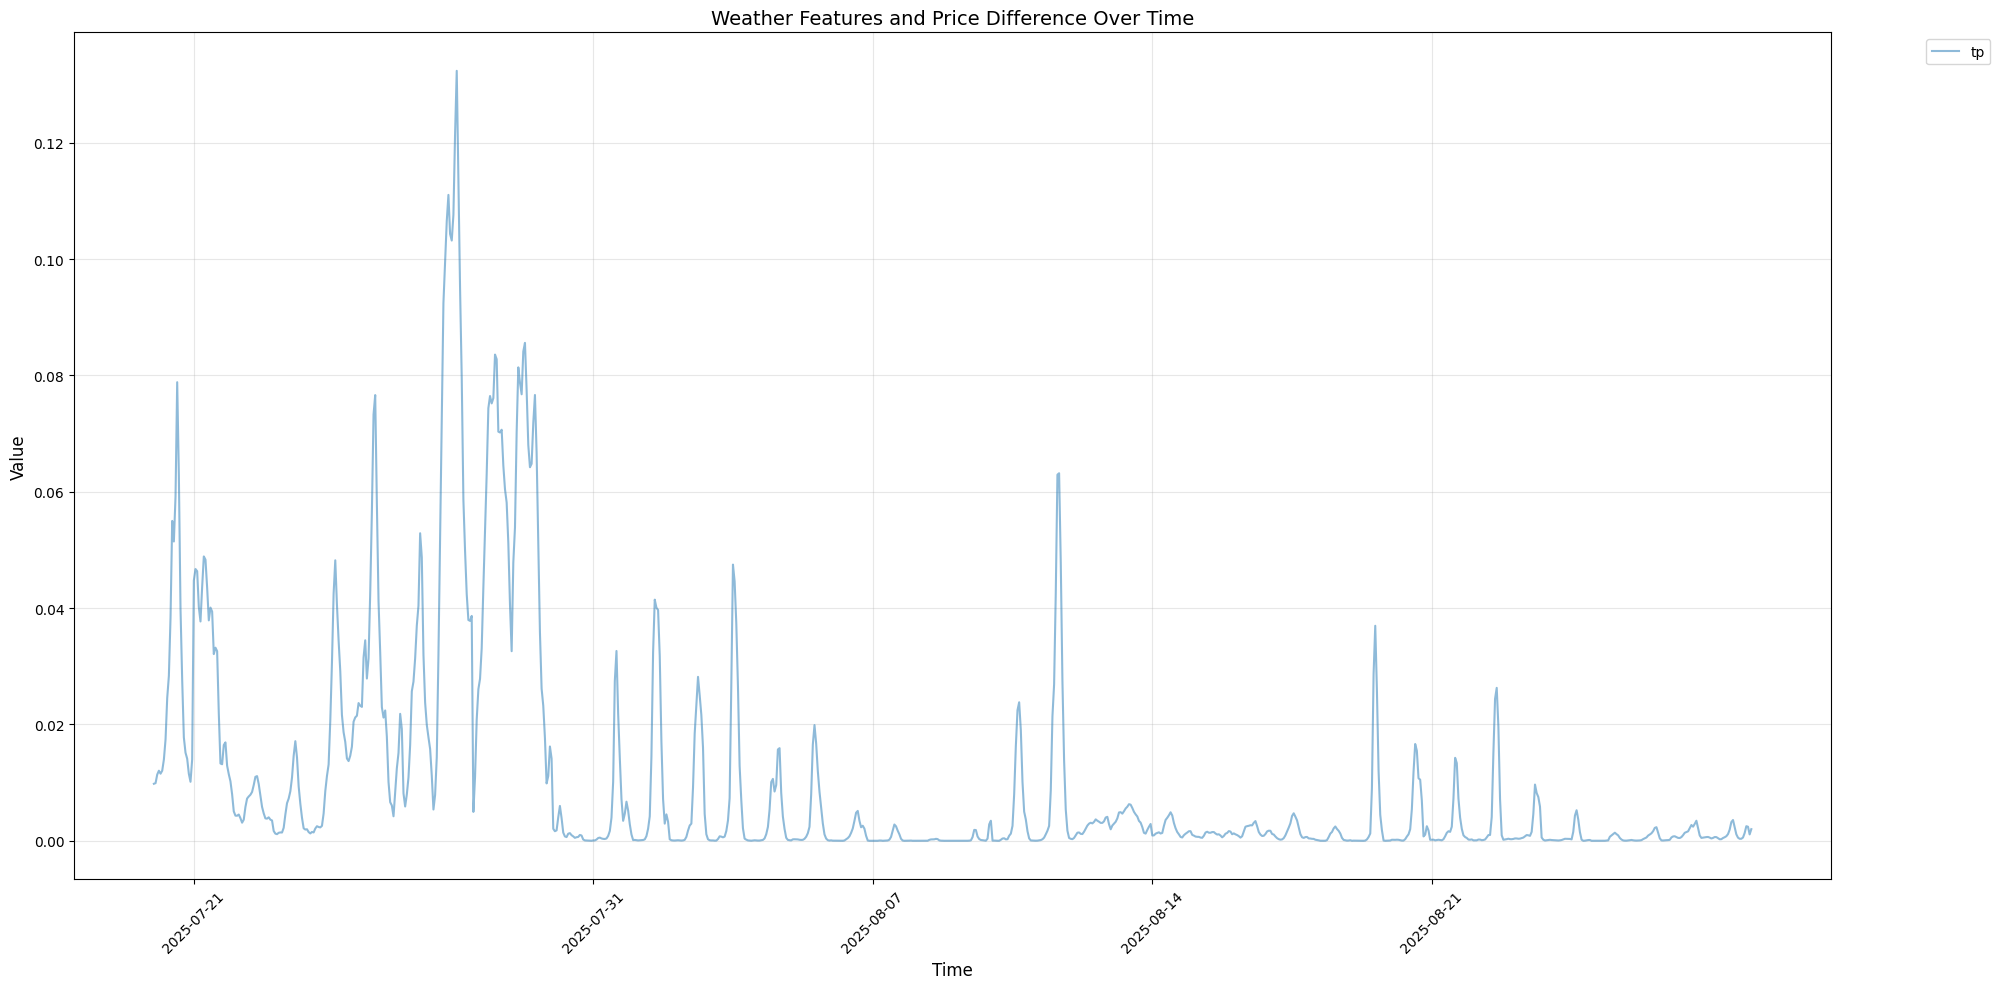

In [8]:

prefixes = [
      #  't2m', 
      #  'd2m', 'skt',
      #  'wbt', 
    #   #  'u10', 'v10',  
      #  'ws10m', 
    #   #  'wd10m',
    #      # 'u100', 'v100', 
        #  'ws100m', 
    #      # 'wd100m',
        #  'u200', 'v200', 
        #  'ws200m', 'wd200m',
      #  'fg10', 
      #  'tcc', 
      #  'lcc', 'mcc', 
      #  'hcc', 'ssr',
      #  'ssr-acc', 'ssrd-acc',
      #  'dsrp-acc', 'fdir-acc', 'par-acc', 'ssrd', 'dsrp', 
      # 'fdir', 
      #  'par',
      #  'tp-acc', 
       'tp',
      #  'tcwv', 
      #  'sp','vis',
        #  'rh','vpd'
]
end_date='20250910'
start_train='20250720'
df=combine_shanxi_pkl_files(end_date, start_train, base_path='/data/energy_market/grid_weather_dadi',n=1) #change provionce
df_plot=df.drop(columns=['latitude', 'longitude','location_name'])
# Create a figure
plt.figure(figsize=(20, 10))
# Create a time frame for better visualization
time_frame = pd.date_range(start='2024-07-30', end='2025-08-30', freq='60min')
df_plot = df_plot[df_plot.index.isin(time_frame)]
# prc_diff = prc_diff[prc_diff.index.isin(time_frame)]
# solar = solar[solar.index.isin(time_frame)]

# Plot all weather features
for features in prefixes:
    feature_means = df_plot.groupby(df_plot.index)[features].mean()
    # Normalize the feature values
    feature_min = df_plot[features].min()
    feature_max = df_plot[features].max()
    if feature_max != feature_min:  # Avoid division by zero
        feature_means = (feature_means - feature_min) / (feature_max - feature_min)

    plt.plot(feature_means.index, feature_means.values, label=features, alpha=0.5)

# Normalize price difference for better visualization
# prc_diff_norm = (prc_diff['diff'] - prc_diff['diff'].min()) / (prc_diff['diff'].max() - prc_diff['diff'].min())
# solar_norm = (solar['solar_n1'] - solar['solar_n1'].min()) / (solar['solar_n1'].max() - solar['solar_n1'].min())
# plt.plot(prc_diff.index, prc_diff_norm, label='Normalized Price Difference', linewidth=1, color='red')
# plt.plot(solar.index, solar_norm, label='Normalized Solar_n1', linewidth=1, color='orange')

# Customize the plot
plt.title('Weather Features and Price Difference Over Time', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tick_params(axis='x', rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()
